# Start coding and Enjoy the journey

## Install the repo

In [2]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [31]:
#IMPORTANTE: Scegli il tuo VPR method! (usa il nome formattato esattamente come nelle cartelle drive)

vpr_method = "mixvpr"

In [ ]:
!pip install wandb

import wandb
wandb.login(key="")

run=wandb.init(
    entity="bea-gn03-politecnico-di-torino",
    project="Progetto_VPR",
    # name="esperimento-1" # Opzionale: scommenta questa riga per dare un nome specifico alla singola run
)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [3]:
!git clone --recursive https://github.com/androsida/Visual-Place-Recognition-Project

Cloning into 'Visual-Place-Recognition-Project'...
remote: Enumerating objects: 353, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (85/85), done.
Receiving objects: 100% (353/353), 8.59 MiB | 10.22 MiB/s, done.
remote: Total 353 (delta 53), reused 0 (delta 0), pack-reused 268 (from 2)
Resolving deltas: 100% (158/158), done.
Submodule 'image-matching-models' (https://github.com/alexstoken/image-matching-models.git) registered for path 'image-matching-models'
Cloning into '/content/Visual-Place-Recognition-Project/image-matching-models'...
remote: Enumerating objects: 2681, done.        
remote: Counting objects: 100% (1023/1023), done.        
remote: Compressing objects: 100% (323/323), done.        
remote: Total 2681 (delta 790), reused 713 (delta 700), pack-reused 1658 (from 3)        
Receiving objects: 100% (2681/2681), 103.57 MiB | 21.24 MiB/s, done.
Resolving deltas: 100% (1855/1855), done.
Submodule path 'image-matching-models': checked o

## Install dependencies

In [ ]:
%cd '/content/Visual-Place-Recognition-Project/image-matching-models'
!pip install -e .[all]

/content/Visual-Place-Recognition-Project/image-matching-models
Obtaining file:///content/Visual-Place-Recognition-Project/image-matching-models
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.3/225.3 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 8

In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 97.8 MB/s eta 0:00:00


## Download Datasets

In [ ]:
%cd /content/Visual-Place-Recognition-Project

!python download_datasets.py

/content/Visual-Place-Recognition-Project
Downloading...
From (original): https://drive.google.com/uc?id=19vrphwImf7lpoaVlKgHhN07AWj_EfhjR
From (redirected): https://drive.google.com/uc?id=19vrphwImf7lpoaVlKgHhN07AWj_EfhjR&confirm=t&uuid=b96e7c14-80a3-4ddd-ba78-0085c788f730
To: /content/Visual-Place-Recognition-Project/data/tokyo_xs.zip
100% 141M/141M [00:03<00:00, 40.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1JaM1y16fArlSF0KPRqCjggMQCIRwXzJm
From (redirected): https://drive.google.com/uc?id=1JaM1y16fArlSF0KPRqCjggMQCIRwXzJm&confirm=t&uuid=ad13ef08-5d20-4698-9b4f-21e3c96f5b14
To: /content/Visual-Place-Recognition-Project/data/sf_xs.zip
100% 1.03G/1.03G [00:32<00:00, 31.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=12nlyYCx-VUZLB2fP8GHQDihzgCiRjpLS
From (redirected): https://drive.google.com/uc?id=12nlyYCx-VUZLB2fP8GHQDihzgCiRjpLS&confirm=t&uuid=65b8fda0-8ff1-4f2c-bdec-1220d1af0fed
To: /content/Visual-Place-Recognition-Project/data/gsv

In [4]:
# da usare se non si riesce a fare il download

%cd /content/Visual-Place-Recognition-Project

!rm -rf data
!mkdir -p data

!cp "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/database_zip/sf_xs.zip" "data/sf_xs.zip"
!cp "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/database_zip/tokyo_xs.zip" "data/tokyo_xs.zip"
!cp "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/database_zip/gsv_xs.zip" "data/gsv_xs.zip"
!cp "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/database_zip/svox.zip" "data/svox.zip"


!unzip -q data/sf_xs.zip -d data/
!unzip -q data/tokyo_xs.zip -d data/
!unzip -q data/gsv_xs.zip -d data/
!unzip -q data/svox.zip -d data/


!rm data/sf_xs.zip
!rm data/tokyo_xs.zip
!rm data/gsv_xs.zip
!rm data/svox.zip

/content/Visual-Place-Recognition-Project


## Run your First VPR Evalutation



In [ ]:
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/validation/Image_Matching_methods/{vpr_method}" \
--method="{vpr_method}" \
--backbone=ResNet50 \
--descriptors_dimension=512 \
--distance_metric="l2" \
--image_size 512 512 \
--database_folder '/content/Visual-Place-Recognition-Project/data/sf_xs/val/database' \
--queries_folder '/content/Visual-Place-Recognition-Project/data/sf_xs/val/queries' \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty


2026-05-20 11:29:59 VPR-methods-evaluation/main.py --num_workers 8 --batch_size 32 --log_dir /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/validation/Image_Matching_methods/cosplace --method=cosplace --backbone=ResNet50 --descriptors_dimension=512 --distance_metric=l2 --image_size 512 512 --database_folder /content/Visual-Place-Recognition-Project/data/sf_xs/val/database --queries_folder /content/Visual-Place-Recognition-Project/data/sf_xs/val/queries --num_preds_to_save 20 --recall_values 1 5 10 20 --save_for_uncertainty
2026-05-20 11:29:59 Arguments: Namespace(positive_dist_threshold=25, method='cosplace', backbone='ResNet50', distance_metric='l2', descriptors_dimension=512, database_folder='/content/Visual-Place-Recognition-Project/data/sf_xs/val/database', queries_folder='/content/Visual-Place-Recognition-Project/data/sf_xs/val/queries', num_workers=8, batch_size=32, log_dir='/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results

## Run Image Matching on Retrieval Results



In [ ]:
!python match_queries_preds.py \
--preds-dir "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/validation/Image_Matching_methods/{vpr_method}/sf_xs/preds" \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20



/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 4.96M/4.96M [00:00<00:00, 119MB/s]
100% 45.3M/45.3M [00:00<00:00, 251MB/s]
100% 7993/7993 [7:58:27<00:00,  3.59s/it]
TIMING - Image matching total time: 28521.507318 s
TIMING - Image matching time per query: 3.568311 s/query


## Check Re-ranking Performance

In [ ]:
!python reranking.py \
--preds-dir '<path-to-predictions-folder>' \
--inliers-dir '<path-to-inliers-folder>' \
--num-preds 20 \
--recall-values 1 5 10 20

## Perform Uncertainty Evalutation

In [ ]:
!python -m vpr_uncertainty.eval \
--preds-dir '<path-to-predictions-folder>' \
--inliers-dir '<path-to-inliers-folder>' \
--z-data-path '<path-to-z-data-file>'

# CALCOLO DEL TEMPO

ricavo del tempo di Image Matching dai fiel .torch

In [ ]:
from pathlib import Path
from datetime import datetime
import numpy as np


folder = Path(f"/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/{vpr_method}/svox/night/preds_loftr")

# Prende tutti i .torch
files = list(folder.glob("*.torch"))

if len(files) == 0:
    raise ValueError(f"Nessun file .torch trovato in {folder}")

# Ordina per timestamp di modifica
files = sorted(files, key=lambda p: p.stat().st_mtime)

# Timestamp in secondi
times = np.array([p.stat().st_mtime for p in files])

first_file = files[0]
last_file = files[-1]

first_time = times[0]
last_time = times[-1]

total_time = last_time - first_time

# Se usiamo primo e ultimo file, gli intervalli sono n_file - 1
avg_time_per_query = total_time / (len(files) - 1) if len(files) > 1 else 0.0

log_text = f"""Cartella: {folder}
Numero file .torch: {len(files)}

Primo file generato:
{first_file.name} - {datetime.fromtimestamp(first_time)}

Ultimo file generato:
{last_file.name} - {datetime.fromtimestamp(last_time)}

Tempo totale stimato:
{total_time:.2f} s
{total_time / 60:.2f} min

Tempo medio stimato per query:
{avg_time_per_query:.6f} s/query
"""

print(log_text)

# Nome file log con timestamp
log_file = folder / f"log_tempo_query.txt"

# Salvataggio
log_file.write_text(log_text, encoding="utf-8")

print(f"Log salvato in:\n{log_file}")

Cartella: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/cosplace/svox/night/preds_loftr
Numero file .torch: 823

Primo file generato:
000.torch - 2026-05-05 15:43:12

Ultimo file generato:
822.torch - 2026-05-05 16:41:39

Tempo totale stimato:
3507.00 s
58.45 min

Tempo medio stimato per query:
4.266423 s/query

Log salvato in:
/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/cosplace/svox/night/preds_loftr/log_tempo_query.txt


per calcolare il tempo totale

In [ ]:
import re
from pathlib import Path

%cd /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/
# 1. IMPOSTAZIONI
datasets = ['sf_xs', 'tokyo_xs', 'svox/sun', 'svox/night']
methods = ['superglue', 'loftr', 'superpoint-lg']
base_dir = Path(f"/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/{vpr_method}")

csv_file = base_dir / "tabella_finale_tempi_query.csv"
csv_lines = ["Dataset,Metodo,Global_Mean_s,Matching_Mean_s,Reranking_Mean_s,Totale_Query_ms\n"]

# 2. REGEX (Catturano i numeri dopo le frasi chiave)
global_avg_pattern = re.compile(r"Single \(mean\) query processing time:[^\d]*(\d+(?:\.\d+)?)", re.IGNORECASE)
match_avg_pattern = re.compile(r"Tempo medio[^\d]*per query:[^\d]*(\d+(?:\.\d+)?)", re.IGNORECASE)
rerank_avg_pattern = re.compile(r"Reranking time per query:[^\d]*(\d+(?:\.\d+)?)", re.IGNORECASE)

print(f"{'DATASET':<12} | {'METODO':<15} | {'TOTALE ms/query':<15}")
print("-" * 50)

# 3. CICLO DI ESTRAZIONE
for ds in datasets:
    dataset_dir = base_dir / ds
    if not dataset_dir.exists(): continue

    # --- A. GLOBAL MEAN ---
    global_avg = 0.0
    # Cerchiamo info.log con asterisco per beccare anche info (1).log o .txt
    log_candidates = list(dataset_dir.rglob("info*log*")) + list(dataset_dir.rglob("info*txt*"))
    if not log_candidates:
        log_candidates = list(dataset_dir.parent.glob("info*log*"))

    if log_candidates:
        latest_log = max(log_candidates, key=lambda f: f.stat().st_mtime)
        with open(latest_log, 'r', encoding='utf-8', errors='ignore') as f:
            m = global_avg_pattern.search(f.read())
            if m: global_avg = float(m.group(1))

    # --- B. MATCHING & RERANKING ---
    for method in methods:
        match_avg, rerank_avg = 0.0, 0.0

        # Matching
        preds_dir = dataset_dir / f"preds_{method}"
        log_match = list(preds_dir.glob("log_tempo_query*"))
        if log_match:
            with open(log_match[0], 'r', encoding='utf-8', errors='ignore') as f:
                m = match_avg_pattern.search(f.read())
                if m: match_avg = float(m.group(1))

        # Reranking
        rerank_files = list(dataset_dir.glob(f"results_reranking_{method}*"))

        if rerank_files:
        # Trova il file modificato più recentemente tra quelli che corrispondono
          latest_rr = max(rerank_files, key=lambda f: f.stat().st_mtime)

          with open(latest_rr, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
            m = rerank_avg_pattern.search(content)
            if m:
              rerank_avg = float(m.group(1))


        # Calcolo Totale in millisecondi
        totale_ms = (global_avg + match_avg + rerank_avg) * 1000

        # Stampa riga tabella a schermo
        print(f"{ds:<12} | {method:<15} | {totale_ms:>8.2f} ms")

        # Aggiungi riga per CSV
        csv_lines.append(f"{ds},{method},{global_avg:.6f},{match_avg:.6f},{rerank_avg:.6f},{totale_ms:.2f}\n")

# 4. SALVATAGGIO
csv_file.write_text("".join(csv_lines))
print("-" * 50)
print(f"\n✅ Tabella salvata in: {csv_file}")

/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project
DATASET      | METODO          | TOTALE ms/query
--------------------------------------------------
sf_xs        | superglue       |  1946.12 ms
sf_xs        | loftr           |  4459.05 ms
sf_xs        | superpoint-lg   |  5941.97 ms
tokyo_xs     | superglue       |  2202.78 ms
tokyo_xs     | loftr           |  4808.41 ms
tokyo_xs     | superpoint-lg   |  4999.58 ms
svox/sun     | superglue       |  1905.57 ms
svox/sun     | loftr           |  4246.27 ms
svox/sun     | superpoint-lg   |  4862.40 ms
svox/night   | superglue       |  2112.25 ms
svox/night   | loftr           |  4286.32 ms
svox/night   | superpoint-lg   |  4593.08 ms
--------------------------------------------------

✅ Tabella salvata in: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/mixvpr/tabella_finale_tempi_query.csv


# ESERCIZIO 5.3

##estrazione inliers per la fase di TEST (Esegui solo se non hai già salvato su Drive il dataframe con gli inliers estratti)

In [33]:
from pathlib import Path
import shutil
from tqdm import tqdm


drive_results = Path("/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results")
local_results = Path("/content/local_results")

if local_results.exists():
    shutil.rmtree(local_results)

local_results.mkdir(parents=True, exist_ok=True)


datasets = ['tokyo_xs', "sf_xs", "svox/sun", "svox/night"]
methods = ['superglue', 'loftr', 'superpoint-lg']

for dataset in datasets:

    # copio SOLO i .txt da preds
    src = drive_results / "Image_Matching_methods" / vpr_method / dataset / "preds"
    dst = local_results / "Image_Matching_methods" / vpr_method / dataset / "preds"

    if src.exists():
        if dst.exists():
            shutil.rmtree(dst)

        dst.mkdir(parents=True, exist_ok=True)

        txt_files = list(src.glob("*.txt"))

        for f in tqdm(txt_files, desc=f"Copia txt {dataset}"):
            shutil.copyfile(f, dst / f.name)

        print(f"Copiati txt: {dataset}")

    # copio i .torch da preds_method
    for method in methods:

        src = drive_results / "Image_Matching_methods" / vpr_method / dataset / f"preds_{method}"
        dst = local_results / "Image_Matching_methods" / vpr_method / dataset / f"preds_{method}"

        if src.exists():
            if dst.exists():
                shutil.rmtree(dst)

            dst.mkdir(parents=True, exist_ok=True)

            torch_files = list(src.glob("*.torch"))

            for f in tqdm(torch_files, desc=f"Copia torch {dataset} / {method}"):
                shutil.copyfile(f, dst / f.name)

            print(f"Copiati torch: {dataset} / {method}")

print("Copia completata.")

Copia txt tokyo_xs: 100%|██████████| 315/315 [00:02<00:00, 121.31it/s]


Copiati txt: tokyo_xs


Copia torch tokyo_xs / superglue: 100%|██████████| 315/315 [00:09<00:00, 31.83it/s] 


Copiati torch: tokyo_xs / superglue


Copia torch tokyo_xs / loftr: 100%|██████████| 315/315 [00:12<00:00, 24.43it/s] 


...

Copiati torch: svox/night / superglue


Copia torch svox/night / loftr: 100%|██████████| 823/823 [00:23<00:00, 35.33it/s] 


Copiati torch: svox/night / loftr


Copia torch svox/night / superpoint-lg: 100%|██████████| 823/823 [01:36<00:00,  8.54it/s]

Copiati torch: svox/night / superpoint-lg
Copia completata.


In [34]:
import torch
import os
import pandas as pd
from glob import glob
from pathlib import Path
from tqdm import tqdm

%cd /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/

# 1. Configurazione Iniziale

datasets = ['tokyo_xs', "sf_xs", "svox/sun", "svox/night"]
methods = ['superglue', 'loftr', 'superpoint-lg']

# LEGGO DA LOCALE: più veloce
base_dir_read = '/content/local_results'

# SALVO SU DRIVE: permanente
base_dir_save = '/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results'

tutti_i_dati = []

# 2. Ciclo di Estrazione Universale

for dataset in datasets:
    for method in methods:

        preds_dir = os.path.join(
            base_dir_read,
            'Image_Matching_methods',
            vpr_method,
            dataset,
            'preds'
        )

        inliers_dir = os.path.join(
            base_dir_read,
            'Image_Matching_methods',
            vpr_method,
            dataset,
            f'preds_{method}'
        )

        if not os.path.exists(inliers_dir) or not os.path.exists(preds_dir):
            print(f"Skip: non trovo {dataset} / {method}")
            continue

        torch_files = sorted(
            glob(os.path.join(inliers_dir, "*.torch")),
            key=lambda p: int(Path(p).stem) if Path(p).stem.isdigit() else Path(p).stem
        )

        for torch_path in tqdm(torch_files, desc=f"Estrazione {dataset}/{method}", leave=False):

            q_name = Path(torch_path).stem
            txt_path = os.path.join(preds_dir, f"{q_name}.txt")

            if not os.path.exists(txt_path):
                continue

            # Lettura Inliers
            try:
                data = torch.load(torch_path, map_location="cpu", weights_only=False)

                if not data:
                    continue

                if isinstance(data, list) and isinstance(data[0], dict) and 'num_inliers' in data[0]:
                    inliers_list = [item['num_inliers'] for item in data]

                elif isinstance(data, dict) and 'num_inliers' in data:
                    inliers_list = [data['num_inliers']]

                else:
                    continue

            except Exception:
                continue

            # Lettura correttezza e nome reale della query
            try:
                with open(txt_path, 'r') as f:
                    content = f.read().splitlines()

                query_start = content.index("Query path:") + 1
                preds_start = content.index("Predictions paths:") + 1
                positives_start = content.index("Positives paths:") + 1

                query_jpg = Path(content[query_start].strip()).name

                predictions = [
                    Path(line.strip()).name
                    for line in content[preds_start:positives_start-1]
                    if line.strip()
                ]

                positives = {
                    Path(line.strip()).name
                    for line in content[positives_start:]
                    if line.strip()
                }

                if not predictions or not positives:
                    continue

            except (ValueError, IndexError):
                continue

            # Calcolo metriche per la riga
            k = min(len(predictions), len(inliers_list))

            if k == 0:
                continue

            base_correct = predictions[0] in positives

            best_idx = max(range(k), key=lambda i: (inliers_list[i], -i))
            full_correct = predictions[best_idx] in positives

            tutti_i_dati.append({
                "dataset": dataset,
                "method": method,
                "query": q_name,
                "query_jpg": query_jpg,
                "rank1_inliers": inliers_list[0],
                "base_correct": base_correct,
                "full_correct": full_correct,
                "k": k
            })


# 3. Creazione del DataFrame globale in memoria

df_risultati = pd.DataFrame(tutti_i_dati)


# 4. Salvataggio su Drive

output_dir = Path(base_dir_save) / "Image_Matching_methods" / vpr_method
output_dir.mkdir(parents=True, exist_ok=True)

pkl_path = output_dir / f"df_risultati_adaptive_{vpr_method}.pkl"
csv_path = output_dir / f"df_risultati_adaptive_{vpr_method}.csv"

df_risultati.to_pickle(pkl_path)
df_risultati.to_csv(csv_path, index=False)

print(f".pkl salvato in: {pkl_path}")
print(f"CSV salvato in: {csv_path}")
print(f"\nEstrazione completata! Tabella creata con {len(df_risultati)} query totali.")

df_risultati.head()

/content/drive/.shortcut-targets-by-id/1RF24y3xBH8DLu-NcbhGNL4sTO05Wsxn_/Progetto_VPR/Visual-Place-Recognition-Project


.pkl salvato in: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/mixvpr/df_risultati_adaptive_mixvpr.pkl
CSV salvato in: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/mixvpr/df_risultati_adaptive_mixvpr.csv

Estrazione completata! Tabella creata con 8874 query totali.


,dataset,method,query,query_jpg,rank1_inliers,base_correct,full_correct,k
0,tokyo_xs,superglue,000,@0381523.71@3946790.15@54@S@035.65786@0139.691...,4,True,True,20
1,tokyo_xs,superglue,001,@0381523.71@3946790.15@54@S@035.65786@0139.691...,4,False,True,20
2,tokyo_xs,superglue,002,@0381523.71@3946790.15@54@S@035.65786@0139.691...,7,False,False,20
3,tokyo_xs,superglue,003,@0381523.71@3946790.15@54@S@035.65786@0139.691...,9,True,True,20
4,tokyo_xs,superglue,004,@0381523.71@3946790.15@54@S@035.65786@0139.691...,14,True,True,20


**Caricamento del dataframe (se presente .pkl) direttamente da drive (evita di rifare il lungo parsing di .torch e .txt sul drive)**

In [35]:
import torch
import os
import pandas as pd
from glob import glob
from pathlib import Path


datasets = ['tokyo_xs', "sf_xs", "svox/sun", "svox/night"]
methods = ['superglue', 'loftr', 'superpoint-lg']

base_dir = Path("/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results")

pkl_path = (
    base_dir
    / "Image_Matching_methods"
    / vpr_method
    / f"df_risultati_adaptive_{vpr_method}.pkl"
)

df_risultati = pd.read_pickle(pkl_path)

print(f"DataFrame caricato: {len(df_risultati)} righe")
df_risultati.head()

DataFrame caricato: 8874 righe


,dataset,method,query,query_jpg,rank1_inliers,base_correct,full_correct,k
0,tokyo_xs,superglue,000,@0381523.71@3946790.15@54@S@035.65786@0139.691...,4,True,True,20
1,tokyo_xs,superglue,001,@0381523.71@3946790.15@54@S@035.65786@0139.691...,4,False,True,20
2,tokyo_xs,superglue,002,@0381523.71@3946790.15@54@S@035.65786@0139.691...,7,False,False,20
3,tokyo_xs,superglue,003,@0381523.71@3946790.15@54@S@035.65786@0139.691...,9,True,True,20
4,tokyo_xs,superglue,004,@0381523.71@3946790.15@54@S@035.65786@0139.691...,14,True,True,20


## creazione istogrammi

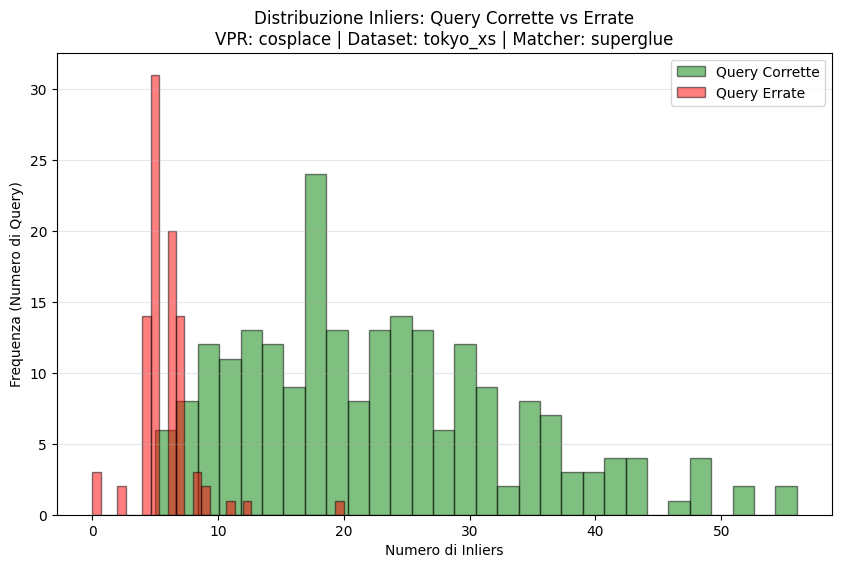

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/tokyo_xs/istogramma_inliers_superglue.png


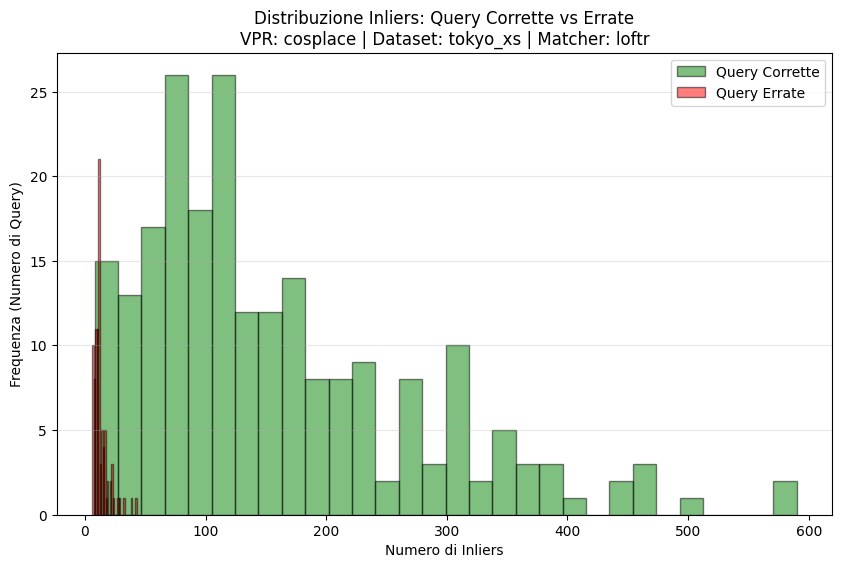

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/tokyo_xs/istogramma_inliers_loftr.png


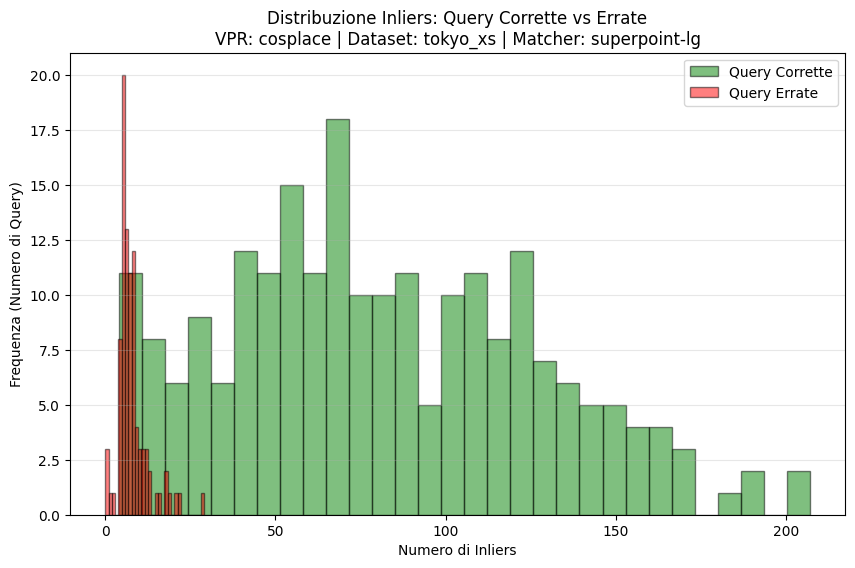

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/tokyo_xs/istogramma_inliers_superpoint-lg.png


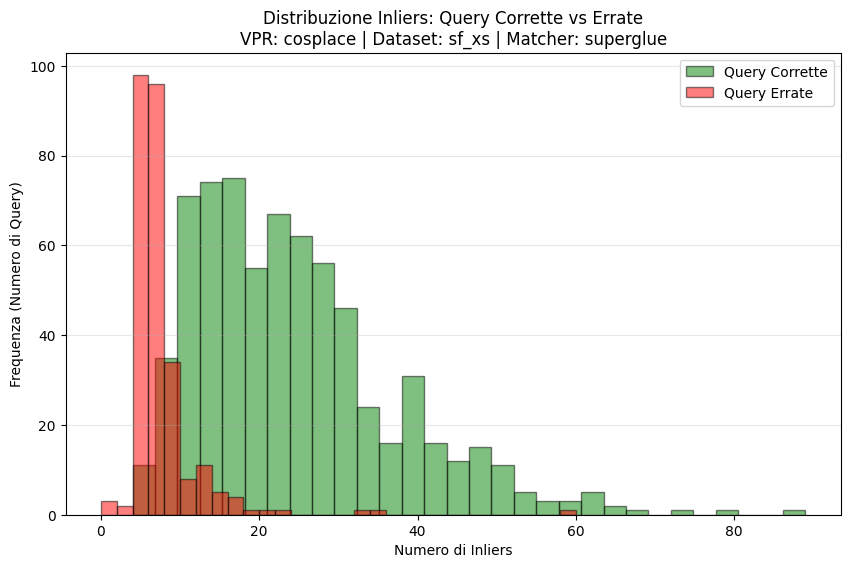

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/sf_xs/istogramma_inliers_superglue.png


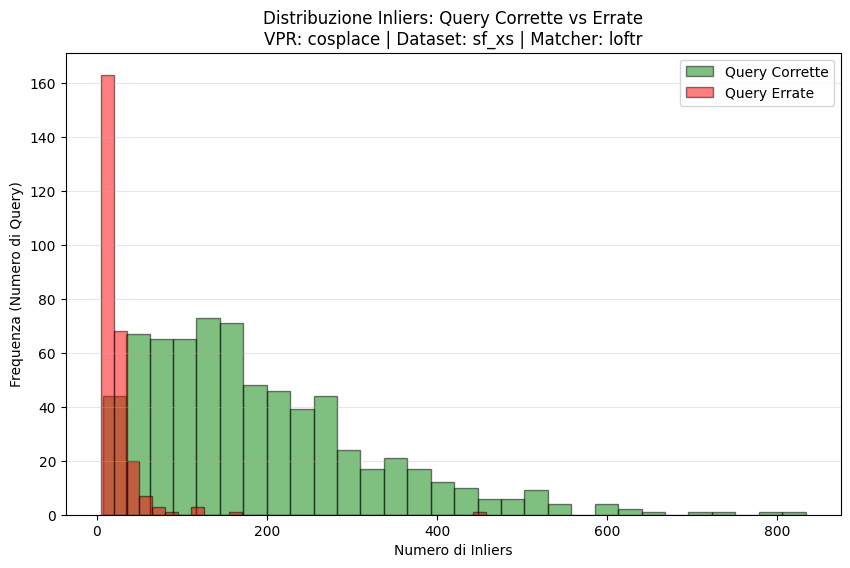

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/sf_xs/istogramma_inliers_loftr.png


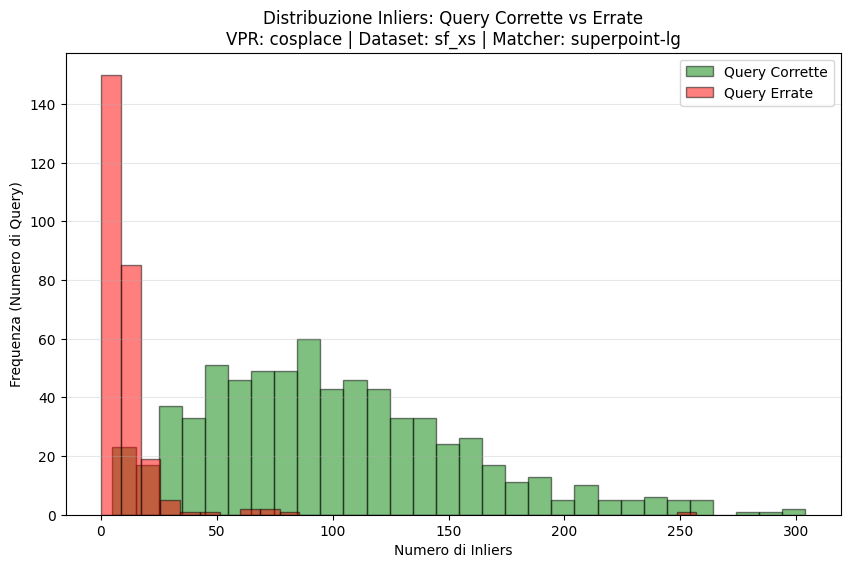

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/sf_xs/istogramma_inliers_superpoint-lg.png


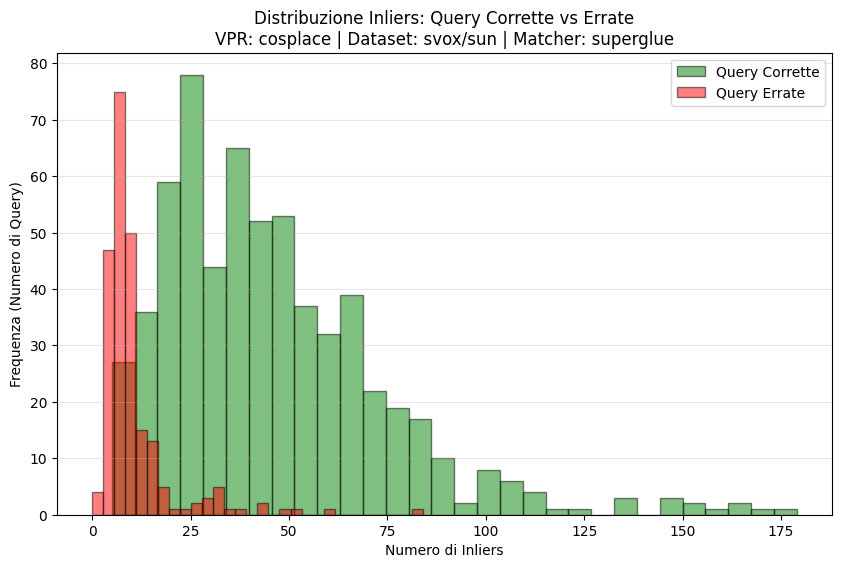

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/sun/istogramma_inliers_superglue.png


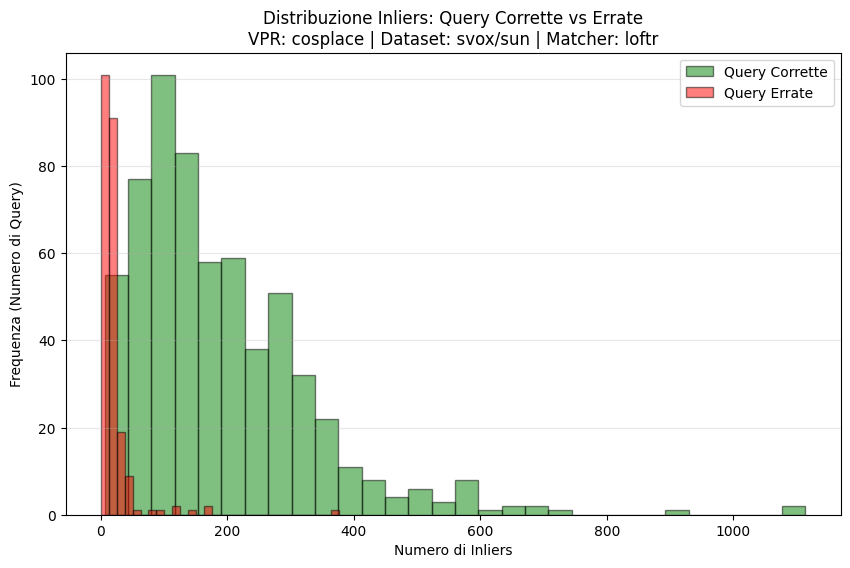

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/sun/istogramma_inliers_loftr.png


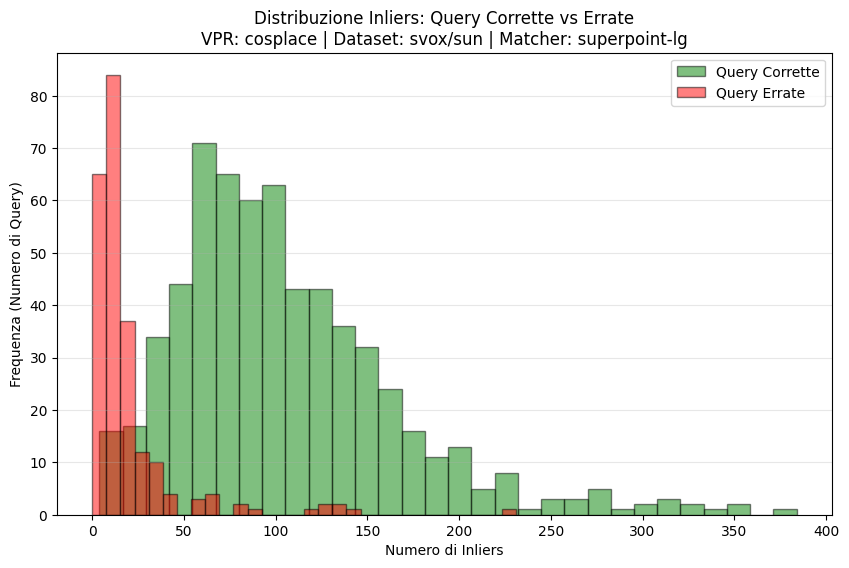

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/sun/istogramma_inliers_superpoint-lg.png


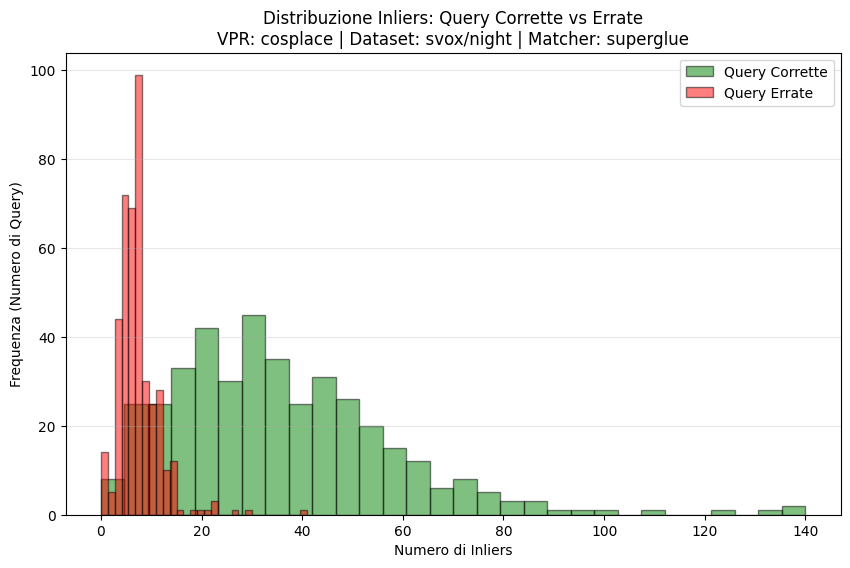

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/night/istogramma_inliers_superglue.png


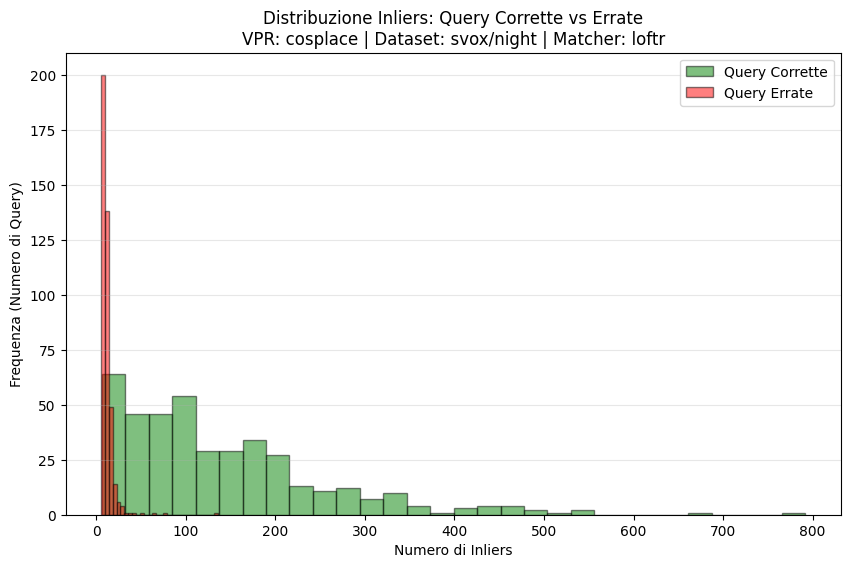

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/night/istogramma_inliers_loftr.png


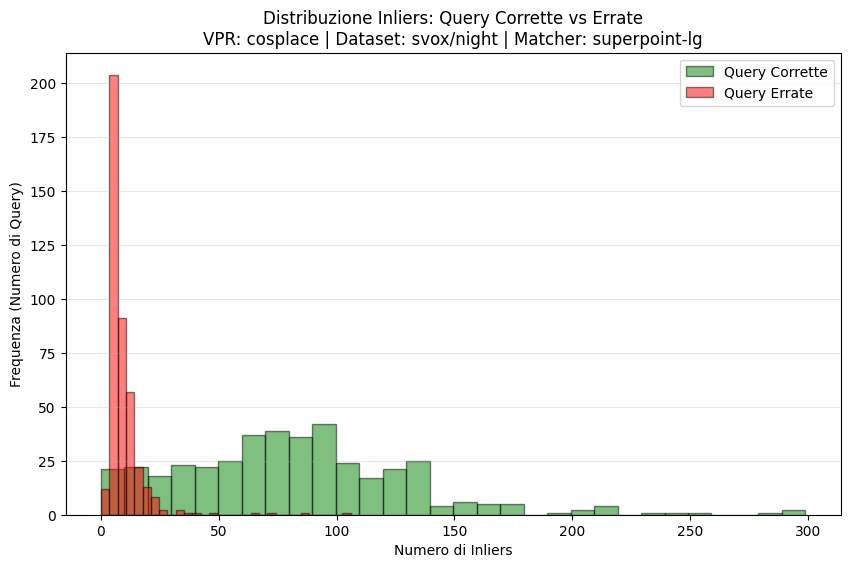

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/night/istogramma_inliers_superpoint-lg.png


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path


# Cicliamo solo per generare i grafici
for dataset in datasets:
    for method in methods:

        # Filtriamo il database in memoria per la combinazione corrente
        df_filtrato = df_risultati[
            (df_risultati['dataset'] == dataset) &
            (df_risultati['method'] == method)
        ]

        if df_filtrato.empty:
            continue

        # Separiamo corretti e sbagliati
        correct_inliers = df_filtrato[df_filtrato['base_correct'] == True]['rank1_inliers']
        wrong_inliers = df_filtrato[df_filtrato['base_correct'] == False]['rank1_inliers']

        plt.figure(figsize=(10, 6))
        plt.hist(correct_inliers, bins=30, alpha=0.5, label='Query Corrette', color='g', edgecolor='black')
        plt.hist(wrong_inliers, bins=30, alpha=0.5, label='Query Errate', color='r', edgecolor='black')

        plt.title(
            f'Distribuzione Inliers: Query Corrette vs Errate\n'
            f'VPR: {vpr_method} | Dataset: {dataset} | Matcher: {method}'
        )
        plt.xlabel('Numero di Inliers')
        plt.ylabel('Frequenza (Numero di Query)')
        plt.legend()
        plt.grid(axis='y', alpha=0.3)

        # Salvataggio dentro la cartella Inliers
        save_dir = (
            Path(base_dir)
            / "Inliers"
            / vpr_method
            / dataset
        )

        save_dir.mkdir(parents=True, exist_ok=True)

        save_path = save_dir / f'istogramma_inliers_{method}.png'

        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

        print(f"✅ Salvato: {save_path}")

##estrazione inliers per la fase di TRAINING (Esegui solo se non hai già salvato su Drive il dataframe con gli inliers estratti)

In [36]:
from pathlib import Path
import shutil
from tqdm import tqdm


drive_results = Path("/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training")
local_results = Path("/content/local_results")

if local_results.exists():
    shutil.rmtree(local_results)

local_results.mkdir(parents=True, exist_ok=True)


datasets = ["svox/sun", "svox/night"]
methods = ['loftr', 'superpoint-lg']

for dataset in datasets:

    # copio SOLO i .txt da preds
    src = drive_results / "Image_Matching_methods" / vpr_method / dataset / "preds"
    dst = local_results / "Image_Matching_methods" / vpr_method / dataset / "preds"

    if src.exists():
        if dst.exists():
            shutil.rmtree(dst)

        dst.mkdir(parents=True, exist_ok=True)

        txt_files = list(src.glob("*.txt"))

        for f in tqdm(txt_files, desc=f"Copia txt {dataset}"):
            shutil.copyfile(f, dst / f.name)

        print(f"Copiati txt: {dataset}")

    # copio i .torch da preds_method
    for method in methods:

        src = drive_results / "Image_Matching_methods" / vpr_method / dataset / f"preds_{method}"
        dst = local_results / "Image_Matching_methods" / vpr_method / dataset / f"preds_{method}"

        if src.exists():
            if dst.exists():
                shutil.rmtree(dst)

            dst.mkdir(parents=True, exist_ok=True)

            torch_files = list(src.glob("*.torch"))

            for f in tqdm(torch_files, desc=f"Copia torch {dataset} / {method}"):
                shutil.copyfile(f, dst / f.name)

            print(f"Copiati torch: {dataset} / {method}")

print("Copia completata.")

Copia txt svox/sun: 100%|██████████| 712/712 [01:06<00:00, 10.72it/s] 


Copiati txt: svox/sun


Copia torch svox/sun / loftr: 100%|██████████| 712/712 [00:31<00:00, 22.80it/s] 


Copiati torch: svox/sun / loftr


Copia torch svox/sun / superpoint-lg: 100%|██████████| 712/712 [01:10<00:00, 10.11it/s]


...

Copiati txt: svox/night


Copia torch svox/night / loftr: 100%|██████████| 702/702 [00:19<00:00, 35.83it/s] 


Copiati torch: svox/night / loftr


Copia torch svox/night / superpoint-lg: 100%|██████████| 702/702 [01:31<00:00,  7.68it/s]

Copiati torch: svox/night / superpoint-lg
Copia completata.


In [37]:
import torch
import os
import pandas as pd
from glob import glob
from pathlib import Path
from tqdm import tqdm

%cd /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/

# 1. Configurazione Iniziale

datasets = ["svox/sun", "svox/night"]
methods = ['loftr', 'superpoint-lg']

# LEGGO DA LOCALE: più veloce
base_dir_read = '/content/local_results'

# SALVO SU DRIVE: permanente
base_dir_save = '/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training'

tutti_i_dati = []

# 2. Ciclo di Estrazione Universale

for dataset in datasets:
    for method in methods:

        preds_dir = os.path.join(
            base_dir_read,
            'Image_Matching_methods',
            vpr_method,
            dataset,
            'preds'
        )

        inliers_dir = os.path.join(
            base_dir_read,
            'Image_Matching_methods',
            vpr_method,
            dataset,
            f'preds_{method}'
        )

        if not os.path.exists(inliers_dir) or not os.path.exists(preds_dir):
            print(f"Skip: non trovo {dataset} / {method}")
            continue

        torch_files = sorted(
            glob(os.path.join(inliers_dir, "*.torch")),
            key=lambda p: int(Path(p).stem) if Path(p).stem.isdigit() else Path(p).stem
        )

        for torch_path in tqdm(torch_files, desc=f"Estrazione {dataset}/{method}", leave=False):

            q_name = Path(torch_path).stem
            txt_path = os.path.join(preds_dir, f"{q_name}.txt")

            if not os.path.exists(txt_path):
                continue

            # Lettura Inliers
            try:
                data = torch.load(torch_path, map_location="cpu", weights_only=False)

                if not data:
                    continue

                if isinstance(data, list) and isinstance(data[0], dict) and 'num_inliers' in data[0]:
                    inliers_list = [item['num_inliers'] for item in data]

                elif isinstance(data, dict) and 'num_inliers' in data:
                    inliers_list = [data['num_inliers']]

                else:
                    continue

            except Exception:
                continue

            # Lettura correttezza e nome reale della query
            try:
                with open(txt_path, 'r') as f:
                    content = f.read().splitlines()

                query_start = content.index("Query path:") + 1
                preds_start = content.index("Predictions paths:") + 1
                positives_start = content.index("Positives paths:") + 1

                query_jpg = Path(content[query_start].strip()).name

                predictions = [
                    Path(line.strip()).name
                    for line in content[preds_start:positives_start-1]
                    if line.strip()
                ]

                positives = {
                    Path(line.strip()).name
                    for line in content[positives_start:]
                    if line.strip()
                }

                if not predictions or not positives:
                    continue

            except (ValueError, IndexError):
                continue

            # Calcolo metriche per la riga
            k = min(len(predictions), len(inliers_list))

            if k == 0:
                continue

            base_correct = predictions[0] in positives

            best_idx = max(range(k), key=lambda i: (inliers_list[i], -i))
            full_correct = predictions[best_idx] in positives

            tutti_i_dati.append({
                "dataset": dataset,
                "method": method,
                "query": q_name,
                "query_jpg": query_jpg,
                "rank1_inliers": inliers_list[0],
                "base_correct": base_correct,
                "full_correct": full_correct,
                "k": k
            })


# 3. Creazione del DataFrame globale in memoria

df_risultati_train = pd.DataFrame(tutti_i_dati)


# 4. Salvataggio su Drive

output_dir = Path(base_dir_save) / "Image_Matching_methods" / vpr_method
output_dir.mkdir(parents=True, exist_ok=True)

pkl_path = output_dir / f"df_risultati_adaptive_{vpr_method}.pkl"
csv_path = output_dir / f"df_risultati_adaptive_{vpr_method}.csv"

df_risultati_train.to_pickle(pkl_path)
df_risultati_train.to_csv(csv_path, index=False)

print(f".pkl salvato in: {pkl_path}")
print(f"CSV salvato in: {csv_path}")
print(f"\nEstrazione completata! Tabella creata con {len(df_risultati_train)} query totali.")

df_risultati_train.head()

/content/drive/.shortcut-targets-by-id/1RF24y3xBH8DLu-NcbhGNL4sTO05Wsxn_/Progetto_VPR/Visual-Place-Recognition-Project


.pkl salvato in: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training/Image_Matching_methods/mixvpr/df_risultati_adaptive_mixvpr.pkl
CSV salvato in: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training/Image_Matching_methods/mixvpr/df_risultati_adaptive_mixvpr.csv

Estrazione completata! Tabella creata con 2828 query totali.


,dataset,method,query,query_jpg,rank1_inliers,base_correct,full_correct,k
0,svox/sun,loftr,000,@0619618.74@5735835.71@20141216_093334@.jpg,16,False,True,20
1,svox/sun,loftr,001,@0619621.28@5735831.24@20141216_093337@.jpg,9,False,True,20
2,svox/sun,loftr,002,@0619622.92@5735844.50@20141216_093327@.jpg,605,True,True,20
3,svox/sun,loftr,003,@0619623.57@5735826.38@20141216_093338@.jpg,9,False,False,20
4,svox/sun,loftr,004,@0619626.69@5735821.63@20141216_093339@.jpg,8,False,True,20


**Caricamento del dataframe (se presente .pkl) direttamente da drive (evita di rifare il lungo parsing di .torch e .txt sul drive)**

In [38]:
import torch
import os
import pandas as pd
from glob import glob
from pathlib import Path


datasets = ["svox/sun", "svox/night"]
methods = ['loftr', 'superpoint-lg']

base_dir = Path("/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training")

pkl_path = (
    base_dir
    / "Image_Matching_methods"
    / vpr_method
    / f"df_risultati_adaptive_{vpr_method}.pkl"
)

df_risultati_train = pd.read_pickle(pkl_path)

print(f"DataFrame caricato: {len(df_risultati_train)} righe")
df_risultati_train.head()

DataFrame caricato: 2828 righe


,dataset,method,query,query_jpg,rank1_inliers,base_correct,full_correct,k
0,svox/sun,loftr,000,@0619618.74@5735835.71@20141216_093334@.jpg,16,False,True,20
1,svox/sun,loftr,001,@0619621.28@5735831.24@20141216_093337@.jpg,9,False,True,20
2,svox/sun,loftr,002,@0619622.92@5735844.50@20141216_093327@.jpg,605,True,True,20
3,svox/sun,loftr,003,@0619623.57@5735826.38@20141216_093338@.jpg,9,False,False,20
4,svox/sun,loftr,004,@0619626.69@5735821.63@20141216_093339@.jpg,8,False,True,20


📊 Dataset selezionato: SVOX/SUN | Matcher: SUPERPOINT-LG
📈 Numero massimo di inliers rilevato al Rank 1: 316

🎯 PUNTO DI INTERSEZIONE (BREAKEVEN) IDENTIFICATO!
Soglia ottima di inliers (tau): 12
Performance all'incrocio -> Recall@1: 79.92% | Cost Saving: 79.07%



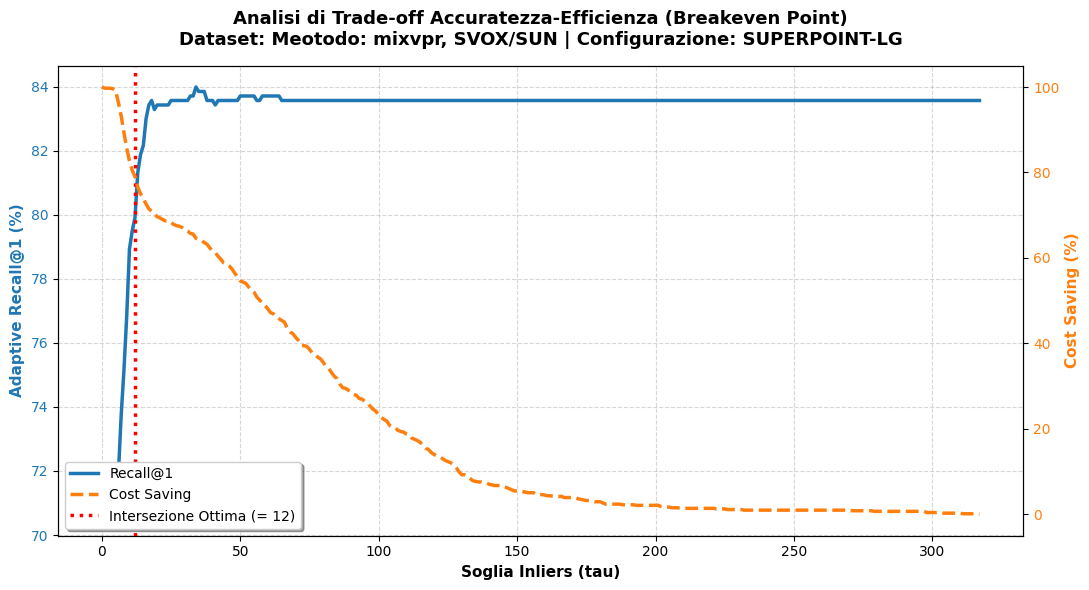

📊 Dataset selezionato: SVOX/SUN | Matcher: LOFTR
📈 Numero massimo di inliers rilevato al Rank 1: 649

🎯 PUNTO DI INTERSEZIONE (BREAKEVEN) IDENTIFICATO!
Soglia ottima di inliers (tau): 14
Performance all'incrocio -> Recall@1: 80.06% | Cost Saving: 79.21%



<Figure size 640x480 with 0 Axes>

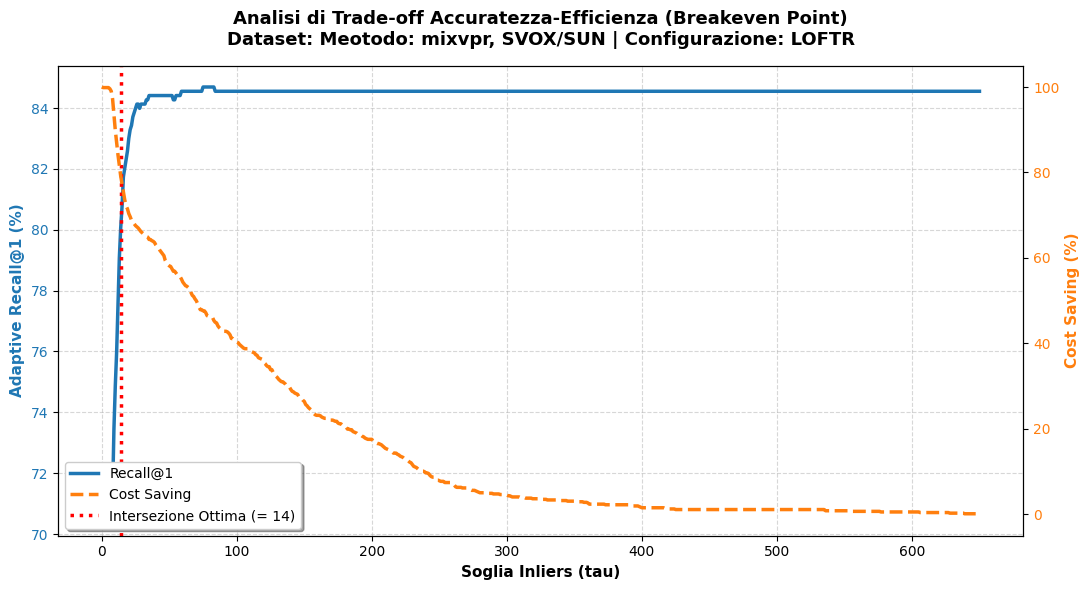

📊 Dataset selezionato: SVOX/NIGHT | Matcher: SUPERPOINT-LG
📈 Numero massimo di inliers rilevato al Rank 1: 218

🎯 PUNTO DI INTERSEZIONE (BREAKEVEN) IDENTIFICATO!
Soglia ottima di inliers (tau): 9
Performance all'incrocio -> Recall@1: 61.54% | Cost Saving: 62.25%



<Figure size 640x480 with 0 Axes>

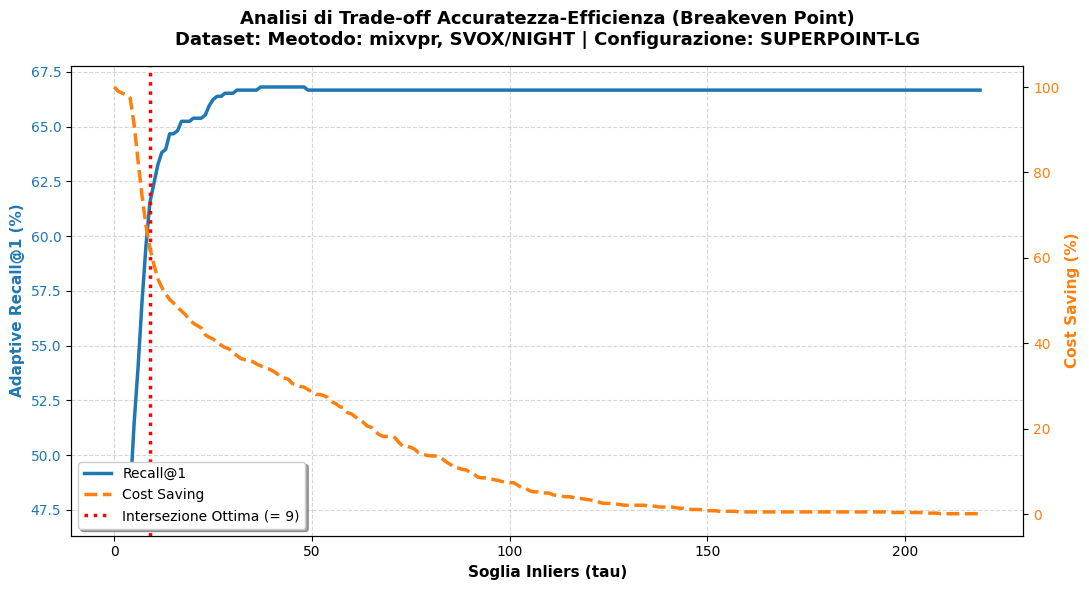

📊 Dataset selezionato: SVOX/NIGHT | Matcher: LOFTR
📈 Numero massimo di inliers rilevato al Rank 1: 498

🎯 PUNTO DI INTERSEZIONE (BREAKEVEN) IDENTIFICATO!
Soglia ottima di inliers (tau): 11
Performance all'incrocio -> Recall@1: 60.11% | Cost Saving: 62.25%



<Figure size 640x480 with 0 Axes>

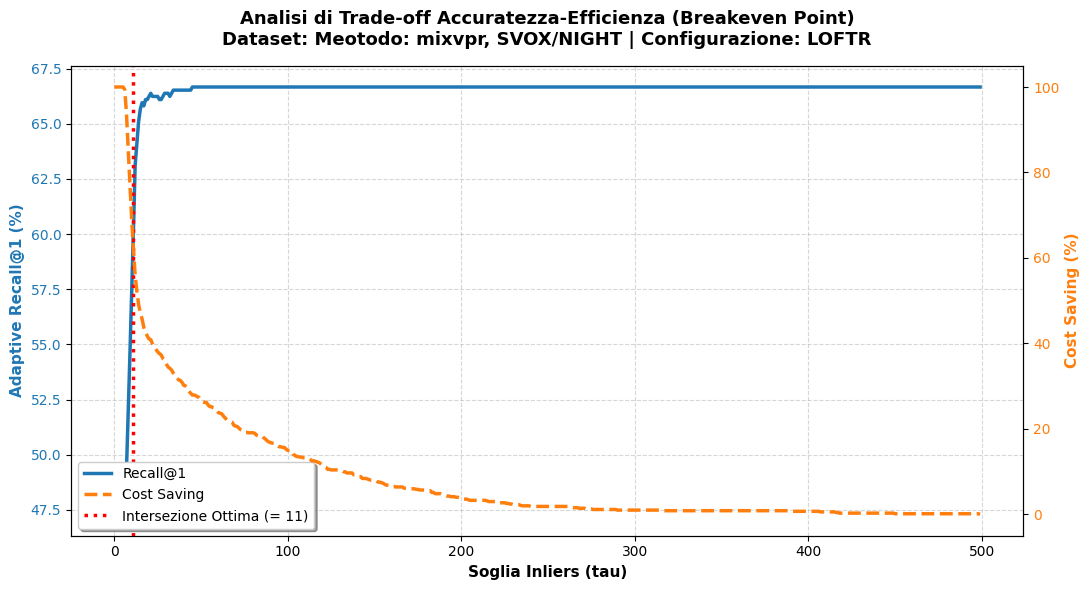

<Figure size 640x480 with 0 Axes>

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


base_dir = Path("/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training")
output_dir = Path(base_dir) / "Image_Matching_methods" / vpr_method

soglia_sun = []
soglia_night = []

# =================================================================
# 1. CONFIGURAZIONE SELEZIONE DATASET E METODO
# =================================================================
# Scegli lo split di training (es. 'svox/sun' o 'svox/night') su cui calcolare la soglia
datasets = ["svox/sun","svox/night"]
methods = ["superpoint-lg","loftr"]
for dataset in datasets:
  for method in methods:
    # Filtriamo il DataFrame globale (df_risultati_train) generato nella cella precedente
    df = df_risultati_train[(df_risultati_train["dataset"] == dataset) &
                            (df_risultati_train["method"] == method)].copy()

    # =================================================================
    # 2. CALCOLO DINAMICO DEL RANGE DI SOGLIE
    # =================================================================
    # Estraiamo il valore massimo di inliers per impostare il limite dell'asse X
    max_inliers = df["rank1_inliers"].max()
    print(f"📊 Dataset selezionato: {dataset.upper()} | Matcher: {method.upper()}")
    print(f"📈 Numero massimo di inliers rilevato al Rank 1: {max_inliers}")
# Generiamo il vettore delle soglie da testare (incluso il valore massimo reale grazie al +2)
    soglie_da_testare = np.arange(0, int(max_inliers) + 2)

    lista_recall = []
    lista_cost_saving = []

    # =================================================================
    # 3. CICLO DI SIMULAZIONE ADAPTIVE RE-RANKING
    # =================================================================
    for tau in soglie_da_testare:
        # REGOLA ADATTIVA:
        # Se inliers < tau -> query difficile -> esegui re-ranking completo (full_correct)
        # Se inliers >= tau -> query facile -> accetta il retrieval puro di base (base_correct)
        adaptive_correct = np.where(
            df["rank1_inliers"] < tau,
            df["full_correct"],
            df["base_correct"]
        )

        # Calcolo della percentuale di Recall@1 Adattivo
        recall_adattivo = adaptive_correct.mean() * 100
        lista_recall.append(recall_adattivo)

        # Calcolo del Cost Saving (% di query che hanno evitato il re-ranking geometrico)
        queries_risparmiate = (df["rank1_inliers"] >= tau).sum()
        cost_saving = (queries_risparmiate / len(df)) * 100
        lista_cost_saving.append(cost_saving)

    # =================================================================
    # 4. CALCOLO MATEMATICO DEL PUNTO DI INTERSEZIONE
    # =================================================================
    arr_recall = np.array(lista_recall)
    arr_cost_saving = np.array(lista_cost_saving)

    # Troviamo la soglia in cui la differenza assoluta tra le due curve è minima
    differenza_assoluta = np.abs(arr_recall - arr_cost_saving)
    indice_intersezione = np.argmin(differenza_assoluta)

    soglia_ottima = soglie_da_testare[indice_intersezione]
    valore_recall_incrocio = arr_recall[indice_intersezione]
    valore_costo_incrocio = arr_cost_saving[indice_intersezione]


    print("\n" + "="*60)
    print(f"🎯 PUNTO DI INTERSEZIONE (BREAKEVEN) IDENTIFICATO!")
    print(f"Soglia ottima di inliers (tau): {soglia_ottima}")
    print(f"Performance all'incrocio -> Recall@1: {valore_recall_incrocio:.2f}% | Cost Saving: {valore_costo_incrocio:.2f}%")
    print("="*60 + "\n")


    if dataset=="svox/sun":
      soglia_sun.append(soglia_ottima)



    else:
      soglia_night.append(soglia_ottima)

    # =================================================================
    # 5. GENERAZIONE DEL GRAFICO A DUE ASSI (TRADE-OFF)
    # =================================================================
    fig, ax1 = plt.subplots(figsize=(11, 6))

    # Configurazione Asse Sinistro (Y1): Recall@1
    color = 'tab:blue'
    ax1.set_xlabel('Soglia Inliers (tau)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Adaptive Recall@1 (%)', color=color, fontsize=11, fontweight='bold')
    line_rec = ax1.plot(soglie_da_testare, lista_recall, color=color, linewidth=2.5, label='Recall@1')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Configurazione Asse Destro (Y2): Cost Saving
    ax2 = ax1.twinx()
    color = 'tab:orange'
    ax2.set_ylabel('Cost Saving (%)', color=color, fontsize=11, fontweight='bold')
    line_cost = ax2.plot(soglie_da_testare, lista_cost_saving, color=color, linewidth=2.5,
                        linestyle='--', label='Cost Saving')
    ax2.tick_params(axis='y', labelcolor=color)

    # Disegna la linea verticale nel punto esatto di intersezione calcolato
    line_v = ax1.axvline(x=soglia_ottima, color='red', linestyle=':', linewidth=2.5,
                        label=f'Intersezione Ottima (= {soglia_ottima})')

    # Unificazione delle legende di assi diversi in un unico box pulito
    lines = line_rec + line_cost + [line_v]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='lower left', frameon=True, shadow=True, facecolor='white')

    # Titolo del grafico
    plt.title(f"Analisi di Trade-off Accuratezza-Efficienza (Breakeven Point)\nDataset: Meotodo: {vpr_method}, {dataset.upper()} | Configurazione: {method.upper()}",
              fontsize=13, fontweight='bold', pad=15)

    fig.tight_layout()
    plt.show()
    plt.savefig(output_dir / dataset / f'Tradeoff_{vpr_method}_{method}', dpi=300, bbox_inches='tight')

# media delle soglie e salvataggio sul file txt

In [ ]:
media_sun = np.mean(soglia_sun)
media_night = np.mean(soglia_night)

txt_path = output_dir / "soglie_medie.txt"

with open(txt_path, "w") as f:

    # =========================
    # SUN
    # =========================
    f.write(f"soglia_sun_superpoint-lg = {soglia_sun[0]}\n")
    f.write(f"soglia_sun_loftr = {soglia_sun[1]}\n")
    f.write(f"media_soglia_sun = {media_sun:.2f}\n\n")

    # =========================
    # NIGHT
    # =========================
    f.write(f"soglia_night_superpoint-lg = {soglia_night[0]}\n")
    f.write(f"soglia_night_loftr = {soglia_night[1]}\n")
    f.write(f"media_soglia_night = {media_night:.2f}\n")

print(f"File salvato in: {txt_path}")

File salvato in: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training/Image_Matching_methods/mixvpr/soglie_medie.txt


##estrazione inliers per la fase di VALIDATION (Esegui solo se non hai già salvato su Drive il dataframe con gli inliers estratti)

In [ ]:
from pathlib import Path
import shutil
from tqdm.auto import tqdm


drive_results = Path("/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/validation")
local_results = Path("/content/local_results")

if local_results.exists():
    shutil.rmtree(local_results)

local_results.mkdir(parents=True, exist_ok=True)


datasets = ["sf_xs"]
methods = ['loftr', 'superpoint-lg']

for dataset in datasets:

    # copio SOLO i .txt da preds (risparmia ulteriore tempo)
    src = drive_results / "Image_Matching_methods" / vpr_method / dataset / "preds"
    dst = local_results / "Image_Matching_methods" / vpr_method / dataset / "preds"

    if src.exists():
        if dst.exists():
            shutil.rmtree(dst)

        dst.mkdir(parents=True, exist_ok=True)

        txt_files = list(src.glob("*.txt"))

        for f in tqdm(txt_files, desc=f"Copio txt {dataset}"):
            shutil.copyfile(f, dst / f.name)

        print(f"Copiati txt: {dataset}")

    # copio i .torch da preds_method
    for method in methods:

        src = drive_results / "Image_Matching_methods" / vpr_method / dataset / f"preds_{method}"
        dst = local_results / "Image_Matching_methods" / vpr_method / dataset / f"preds_{method}"

        if src.exists():
            if dst.exists():
                shutil.rmtree(dst)

            dst.mkdir(parents=True, exist_ok=True)

            torch_files = list(src.glob("*.torch"))

            for f in tqdm(torch_files, desc=f"Copio torch {dataset} / {method}"):
                shutil.copyfile(f, dst / f.name)

            print(f"Copiati torch: {dataset} / {method}")

print("Copia completata.")

Copio txt sf_xs:   0%|          | 0/7993 [00:00<?, ?it/s]

In [ ]:
import torch
import os
import pandas as pd
from glob import glob
from pathlib import Path
from tqdm import tqdm

%cd /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/

# 1. Configurazione Iniziale

datasets = ["sf_xs"]
methods = ['superpoint-lg', 'loftr']

# LEGGO DA LOCALE: più veloce
base_dir_read = '/content/local_results'

# SALVO SU DRIVE: permanente
base_dir_save = '/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/validation'

tutti_i_dati = []

# 2. Ciclo di Estrazione Universale

for dataset in datasets:
    for method in methods:

        preds_dir = os.path.join(
            base_dir_read,
            'Image_Matching_methods',
            vpr_method,
            dataset,
            'preds'
        )

        inliers_dir = os.path.join(
            base_dir_read,
            'Image_Matching_methods',
            vpr_method,
            dataset,
            f'preds_{method}'
        )

        if not os.path.exists(inliers_dir) or not os.path.exists(preds_dir):
            print(f"Skip: non trovo {dataset} / {method}")
            continue

        torch_files = sorted(
            glob(os.path.join(inliers_dir, "*.torch")),
            key=lambda p: int(Path(p).stem) if Path(p).stem.isdigit() else Path(p).stem
        )

        for torch_path in tqdm(torch_files, desc=f"Estrazione {dataset}/{method}", leave=False):

            q_name = Path(torch_path).stem
            txt_path = os.path.join(preds_dir, f"{q_name}.txt")

            if not os.path.exists(txt_path):
                continue

            # Lettura Inliers
            try:
                data = torch.load(torch_path, map_location="cpu", weights_only=False)

                if not data:
                    continue

                if isinstance(data, list) and isinstance(data[0], dict) and 'num_inliers' in data[0]:
                    inliers_list = [item['num_inliers'] for item in data]

                elif isinstance(data, dict) and 'num_inliers' in data:
                    inliers_list = [data['num_inliers']]

                else:
                    continue

            except Exception:
                continue

            # Lettura correttezza e nome reale della query
            try:
                with open(txt_path, 'r') as f:
                    content = f.read().splitlines()

                query_start = content.index("Query path:") + 1
                preds_start = content.index("Predictions paths:") + 1
                positives_start = content.index("Positives paths:") + 1

                query_jpg = Path(content[query_start].strip()).name

                predictions = [
                    Path(line.strip()).name
                    for line in content[preds_start:positives_start-1]
                    if line.strip()
                ]

                positives = {
                    Path(line.strip()).name
                    for line in content[positives_start:]
                    if line.strip()
                }

                if not predictions or not positives:
                    continue

            except (ValueError, IndexError):
                continue

            # Calcolo metriche per la riga
            k = min(len(predictions), len(inliers_list))

            if k == 0:
                continue

            base_correct = predictions[0] in positives

            best_idx = max(range(k), key=lambda i: (inliers_list[i], -i))
            full_correct = predictions[best_idx] in positives

            tutti_i_dati.append({
                "dataset": dataset,
                "method": method,
                "query": q_name,
                "query_jpg": query_jpg,
                "rank1_inliers": inliers_list[0],
                "base_correct": base_correct,
                "full_correct": full_correct,
                "k": k
            })


# 3. Creazione del DataFrame globale in memoria

df_risultati_validation = pd.DataFrame(tutti_i_dati)


# 4. Salvataggio su Drive

output_dir = Path(base_dir_save) / "Image_Matching_methods" / vpr_method
output_dir.mkdir(parents=True, exist_ok=True)

pkl_path = output_dir / f"df_risultati_adaptive_{vpr_method}.pkl"
csv_path = output_dir / f"df_risultati_adaptive_{vpr_method}.csv"

df_risultati_validation.to_pickle(pkl_path)
df_risultati_validation.to_csv(csv_path, index=False)

print(f".pkl salvato in: {pkl_path}")
print(f"CSV salvato in: {csv_path}")
print(f"\nEstrazione completata! Tabella creata con {len(df_risultati_validation)} query totali.")

df_risultati_validation.head()

**Caricamento del dataframe (se presente .pkl) direttamente da drive (evita di rifare il lungo parsing di .torch e .txt sul drive)**

In [ ]:
import torch
import os
import pandas as pd
from glob import glob
from pathlib import Path


datasets = ["sf_xs"]
methods = ['loftr', 'superpoint-lg']

base_dir = Path("/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/validation")

pkl_path = (
    base_dir
    / "Image_Matching_methods"
    / vpr_method
    / f"df_risultati_adaptive_{vpr_method}.pkl"
)

df_risultati_validation = pd.read_pickle(pkl_path)

print(f"DataFrame caricato: {len(df_risultati_validation)} righe")
df_risultati_validation.head()

# LUMINANZA
-- PIANO A

In [ ]:
# TRAINING PHASE ON SVOX/SUN AND SVOX/NIGHT FOR LUMINANCE

import torch
import os
import tqdm
import pandas as pd
import numpy as np
from glob import glob
from pathlib import Path
from PIL import Image
import torchvision.transforms as transforms

dataset_dir = Path("/content/Visual-Place-Recognition-Project/data/svox/images/train")


def luminance_mean(path):
  transform = transforms.Compose([
    transforms.ToTensor()
])

  # Load RGB image
  image = Image.open(path).convert("RGB")
  tensor = transform(image)
  # Convert sRGB values to linear RGB
  linearized_tensor = torch.where(tensor <= 0.04045,tensor / 12.92,((tensor + 0.055) / 1.055) ** 2.4)

  # Extract RGB channels
  R = linearized_tensor[0]
  G = linearized_tensor[1]
  B = linearized_tensor[2]

  # Compute luminance
  Y = 0.2126 * R + 0.7152 * G + 0.0722 * B

  # Return mean luminance of the image
  Y_mean = torch.mean(Y)
  return Y_mean


svox_sun_path = dataset_dir / "queries_sun"
svox_night_path = dataset_dir / "queries_night"

svox_sun_images = glob(os.path.join(svox_sun_path, "*.jpg"))
svox_night_images= glob(os.path.join(svox_night_path, "*.jpg"))

luminance_sun_mean = np.zeros(len(svox_sun_images))
luminance_night_mean = np.zeros(len(svox_night_images))

# Compute luminance for sun images
for i, path in enumerate(tqdm.tqdm(svox_sun_images)):
  luminance_sun_mean[i] = luminance_mean(path)

# Compute luminance for night images
for i, path in enumerate(tqdm.tqdm(svox_night_images)):
  luminance_night_mean[i] = luminance_mean(path)


print("\n")
print("Sun (mean,std):", luminance_sun_mean.mean(), luminance_sun_mean.std())
print("Night (mean,std):", luminance_night_mean.mean(), luminance_night_mean.std())
print("Sun range (min,max):", luminance_sun_mean.min(), luminance_sun_mean.max())
print("Night range (min,max):", luminance_night_mean.min(), luminance_night_mean.max())

# percentili
print("Sun 2% percentile:",np.percentile(luminance_sun_mean, 2))
print("Night 98% percentile:",np.percentile(luminance_night_mean, 98))



100%|██████████| 702/702 [00:05<00:00, 121.82it/s]



Sun (mean,std): 0.4399621281144994 0.0806294251991261
Night (mean,std): 0.14815988890465848 0.0473096295971037
Sun range (min,max): 0.15649046003818512 0.9961574673652649
Night range (min,max): 0.03146157041192055 0.2262282818555832
Sun 2% percentile: 0.3194774842262268
Night 98% percentile: 0.20891928613185884


Grafico

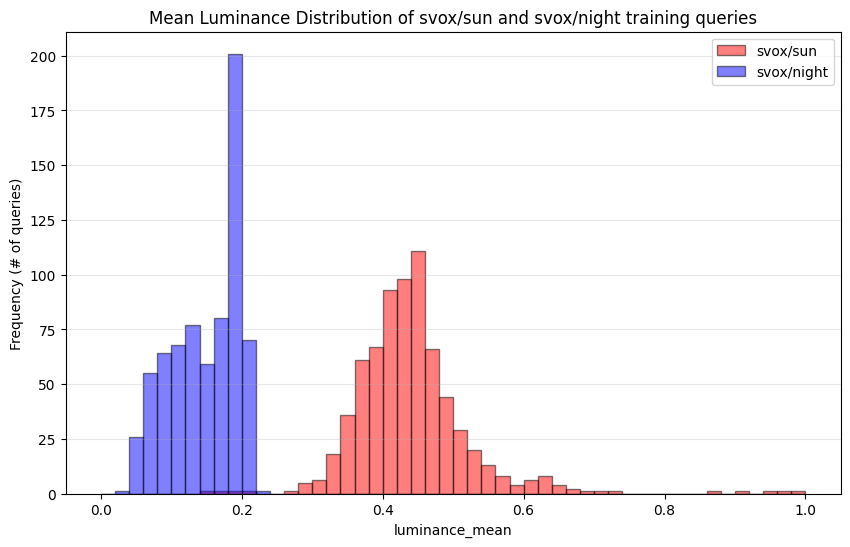

In [ ]:
import matplotlib.pyplot as plt

bins = np.linspace(0,1,51)

plt.figure(figsize=(10, 6))
plt.hist(luminance_sun_mean, bins=bins, alpha=0.5, label='svox/sun', color='red', edgecolor='black')
plt.hist(luminance_night_mean, bins=bins, alpha=0.5, label='svox/night', color='blue', edgecolor='black')
plt.title('Mean Luminance Distribution of svox/sun and svox/night training queries')
plt.xlabel('luminance_mean')
plt.ylabel('Frequency (# of queries)')
plt.legend()
plt.grid(axis='y', alpha=0.3)



$$\frac{T- \mu_{night}}{\sigma_{nigth}} = \frac{T- \mu_{sun}}{\sigma_{sun}} $$

In [ ]:
# COMPUTE OPTIMAL LUMINANCE THRESHOLD

mu_sun, std_sun = luminance_sun_mean.mean(), luminance_sun_mean.std()
mu_night, std_night = luminance_night_mean.mean(), luminance_night_mean.std()

# optimal value
threshold_luminance_mean = (mu_night * std_sun + mu_sun * std_night) / (std_sun + std_night)

print(f"Optimal luminance threshold: {threshold_luminance_mean:.4f}")

Optimal luminance threshold: 0.2561


In [ ]:
# VALIDATION PHASE FOR LUMINANCE ON SF_XS

dataset_dir = Path("/content/Visual-Place-Recognition-Project/data/sf_xs/val/queries")

sfxs_images = glob(os.path.join(dataset_dir, "**/*.jpg"), recursive=True)
luminances_sfxs_mean = np.zeros(len(sfxs_images))

print("Estrazione luminanza in corso...")
for i, path in enumerate(tqdm.tqdm(sfxs_images)):
    luminances_sfxs_mean[i] = luminance_mean(path)

print("\n")
print("Sf_xs (mean,std):", luminances_sfxs_mean.mean(), luminances_sfxs_mean.std())
print("Sf_xs range (min,max):", luminances_sfxs_mean.min(), luminances_sfxs_mean.max())


Estrazione luminanza in corso...


100%|██████████| 7993/7993 [00:24<00:00, 320.06it/s]



Sf_xs (mean,std): 0.27491665478242544 0.09675779500718686
Sf_xs range (min,max): 0.018521208316087723 0.7215548157691956


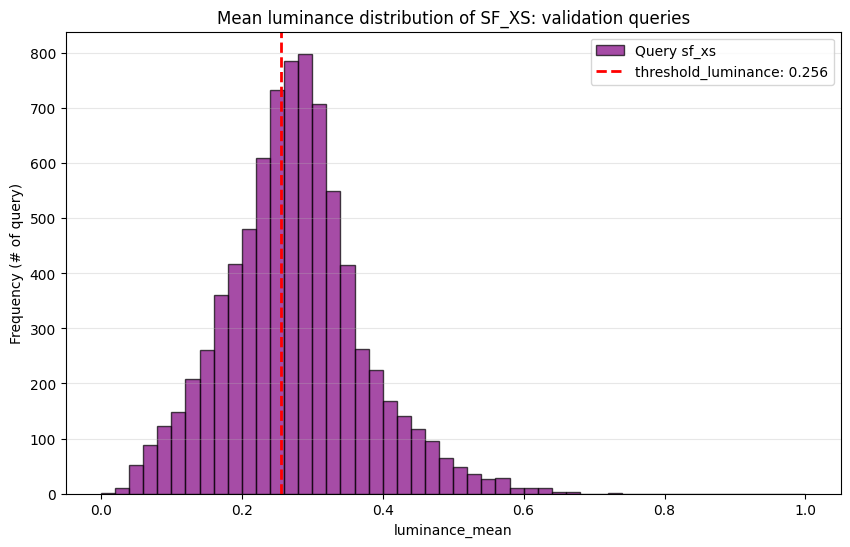

Risultati su 7993 immagini:
GIORNO (Corrette): 4677 (58.51%)
NOTTE (Errori):    3316 (41.49%)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bins = np.linspace(0, 1, 51)

plt.hist(luminances_sfxs_mean, bins=bins, alpha=0.7, color='purple', edgecolor='black', label='Query sf_xs')
plt.axvline(threshold_luminance_mean, color='red', linestyle='dashed', linewidth=2, label=f'threshold_luminance: {threshold_luminance_mean:.3f}')

plt.title('Mean luminance distribution of SF_XS: validation queries')
plt.xlabel('luminance_mean')
plt.ylabel('Frequency (# of query)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


# Validazione
total = len(luminances_sfxs_mean)
predicted_day = np.sum(luminances_sfxs_mean > threshold_luminance_mean)
predicted_night = np.sum(luminances_sfxs_mean <= threshold_luminance_mean)

perc_day = (predicted_day / total) * 100
perc_night = (predicted_night / total) * 100

print(f"Risultati su {total} immagini:")
print(f"GIORNO (Corrette): {predicted_day} ({perc_day:.2f}%)")
print(f"NOTTE (Errori):    {predicted_night} ({perc_night:.2f}%)")


Trovati 3316 errori. Visualizzazione delle prime 6 immagini:


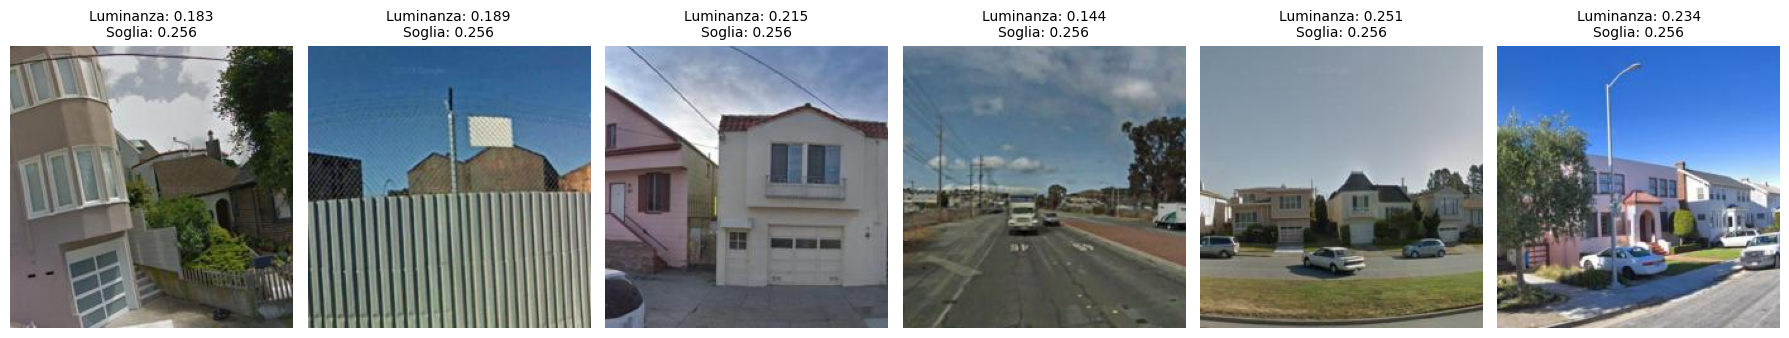

In [ ]:
import matplotlib.pyplot as plt

# Identifica gli indici delle immagini che sono sotto la soglia (notte)
indici_errori = np.where(luminances_sfxs_mean <= threshold_luminance_mean)[0]

max_immagini_da_mostrare = 6
immagini_da_mostrare = indici_errori[:max_immagini_da_mostrare]

if len(indici_errori) == 0:
    print("Ottimo! Non ci sono errori da visualizzare. Tutte le immagini superano la soglia.")
else:
    print(f"Trovati {len(indici_errori)} errori. Visualizzazione delle prime {len(immagini_da_mostrare)} immagini:")

    fig, axes = plt.subplots(1, len(immagini_da_mostrare), figsize=(18, 5))

    if len(immagini_da_mostrare) == 1:
        axes = [axes]

    for i, idx in enumerate(immagini_da_mostrare):
        path_immagine = sfxs_images[idx]
        luminanza_val = luminances_sfxs_mean[idx]

        img = Image.open(path_immagine)

        axes[i].imshow(img)
        axes[i].set_title(f"Luminanza: {luminanza_val:.3f}\nSoglia: {threshold_luminance_mean:.3f}", fontsize=10)
        axes[i].axis('off') # Nasconde gli assi coordinati

    plt.tight_layout()
    plt.show()

# PIANO B




In [9]:
import cv2
import numpy as np
from tqdm import tqdm

dataset_dir = Path("/content/Visual-Place-Recognition-Project/data/svox/images/train")

def luminance_cv2(path) :

  img_bgr = cv2.imread(path)

  # spazio HLS (0: Tonalità, 1: Luminosità, 2: Saturazione)
  img_hls = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HLS)

  L_channel = img_hls[:, :, 1]
  S_channel = img_hls[:, :, 2]

  L_flat = L_channel.flatten()
  S_flat = S_channel.flatten()

  L_mean = np.mean(L_flat) / 255.0
  S_mean = np.mean(S_flat) / 255.0

  return L_mean, S_mean


svox_sun_path = dataset_dir / "queries_sun"
svox_night_path = dataset_dir / "queries_night"

svox_sun_images = glob(os.path.join(svox_sun_path, "*.jpg"))
svox_night_images= glob(os.path.join(svox_night_path, "*.jpg"))

#numero di queries
num_sun = len(svox_sun_images)
num_night = len(svox_night_images)

#pre-allocamento
L_sun, S_sun = np.zeros(num_sun), np.zeros(num_sun)
L_night, S_night = np.zeros(num_night), np.zeros(num_night)

for i, path in enumerate(tqdm(svox_sun_images)):
  L_sun[i], S_sun[i] = luminance_cv2(path)

for i, path in enumerate(tqdm(svox_night_images)):
  L_night[i], S_night[i] = luminance_cv2(path)

print("\n")
print(f"SUN: luminance (mean, std): {L_sun.mean():.4f}, {L_sun.std():.4f}")
print(f"SUN: saturation (mean, std): {S_sun.mean():.4f}, {S_sun.std():.4f}")
print("-")
print(f"NIGHT: luminance (mean, std): {L_night.mean():.4f}, {L_night.std():.4f}")
print(f"NIGHT: saturation (mean, std): {S_night.mean():.4f}, {S_night.std():.4f}")



100%|██████████| 702/702 [00:02<00:00, 238.27it/s]



SUN: luminance (mean, std): 0.6143, 0.0666
SUN: saturation (mean, std): 0.3800, 0.0760
-
NIGHT: luminance (mean, std): 0.2567, 0.0575
NIGHT: saturation (mean, std): 0.6448, 0.0978


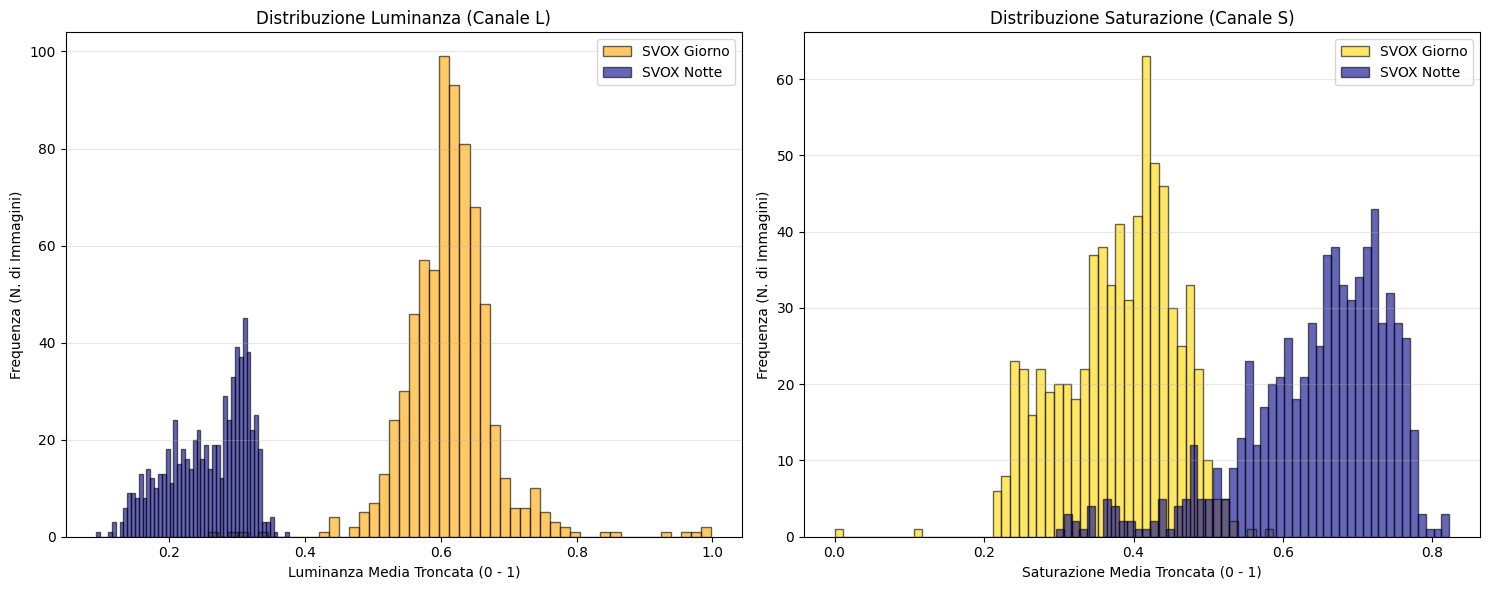

Optimal luminance threshold: 0.4817
Optimal saturation threshold: 0.5667


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# GRAFICO LUMINANZA
axes[0].hist(L_sun, bins=50, alpha=0.6, color='orange', edgecolor='black', label='SVOX Giorno')
axes[0].hist(L_night, bins=50, alpha=0.6, color='darkblue', edgecolor='black', label='SVOX Notte')
axes[0].set_title('Distribuzione Luminanza (Canale L)')
axes[0].set_xlabel('Luminanza Media Troncata (0 - 1)')
axes[0].set_ylabel('Frequenza (N. di Immagini)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# GRAFICO SATURAZIONE
axes[1].hist(S_sun, bins=50, alpha=0.6, color='gold', edgecolor='black', label='SVOX Giorno')
axes[1].hist(S_night, bins=50, alpha=0.6, color='darkblue', edgecolor='black', label='SVOX Notte')
axes[1].set_title('Distribuzione Saturazione (Canale S)')
axes[1].set_xlabel('Saturazione Media Troncata (0 - 1)')
axes[1].set_ylabel('Frequenza (N. di Immagini)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

threshold_luminance_cv = (L_night.mean() * S_sun.mean() + L_sun.mean() * S_night.mean()) / (S_sun.mean() + S_night.mean())
print(f"Optimal luminance threshold: {threshold_luminance_cv:.4f}")

threshold_saturation_cv = (S_night.mean() * L_sun.mean() + S_sun.mean() * L_night.mean()) / (L_sun.mean() + L_night.mean())
print(f"Optimal saturation threshold: {threshold_saturation_cv:.4f}")

In [ ]:
# VALIDAZIONE SU SF_XS
dataset_dir = Path("/content/Visual-Place-Recognition-Project/data/sf_xs/val/queries")

sfxs_images = glob(os.path.join(dataset_dir, "**/*.jpg"), recursive=True)

num_sfxs = len(sfxs_images)
L_sfxs, S_sfxs = np.zeros(num_sfxs), np.zeros(num_sfxs)

for i, path in enumerate(tqdm(sfxs_images)):
    L_sfxs[i], S_sfxs[i] = luminance_cv2(path)

print("\n")
print(f"SF_XS: luminance (mean, std): {L_sfxs.mean():.4f}, {L_sfxs.std():.4f}")
print(f"SF_XS; saturation (mean, std): {S_sfxs.mean():.4f}, {S_sfxs.std():.4f}")


100%|██████████| 7993/7993 [00:07<00:00, 1099.19it/s]



SF_XS: luminance (mean, std): 0.4972, 0.1025
SF_XS; saturation (mean, std): 0.1811, 0.1000


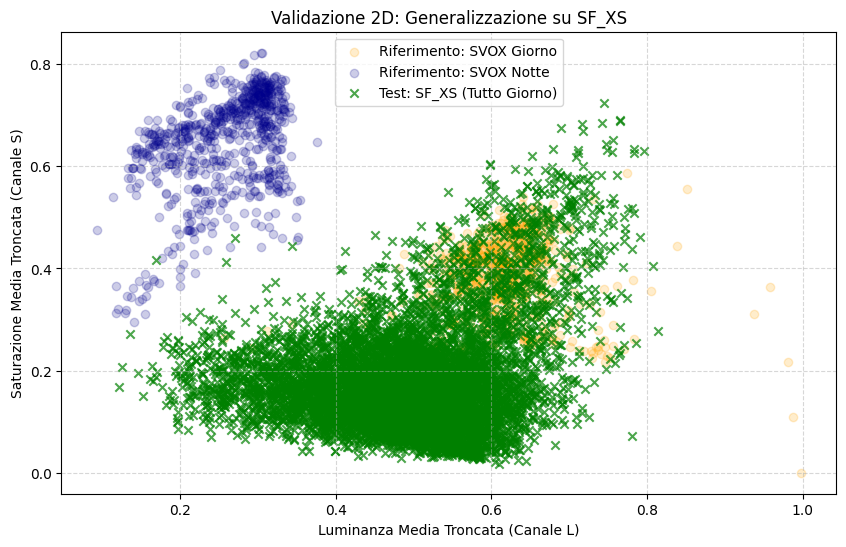

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Disegniamo il "Training Set" (SVOX) in background con alpha=0.2 (molto trasparente)
plt.scatter(L_sun, S_sun, c='orange', alpha=0.2, label='Riferimento: SVOX Giorno')
plt.scatter(L_night, S_night, c='darkblue', alpha=0.2, label='Riferimento: SVOX Notte')

# Disegniamo il "Validation Set" (SF_XS) in primo piano con delle 'x' verdi
plt.scatter(L_sfxs, S_sfxs, c='green', marker='x', alpha=0.7, label='Test: SF_XS (Tutto Giorno)')

plt.title('Validazione 2D: Generalizzazione su SF_XS')
plt.xlabel('Luminanza Media Troncata (Canale L)')
plt.ylabel('Saturazione Media Troncata (Canale S)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

è uno scatter plot che rileva la sovrapposizione dei puntini, quelli di sf_xs sono totalmente sovrapposti a svox/sun lasciando svox/night libero

In [ ]:
# Verifica di errore
import json

def classifica_immagine(L_mean, S_mean):
    if L_mean > threshold_luminance_cv:    #sicuri giorno
        return "Giorno"
    elif L_mean > 0.25 and S_mean < threshold_saturation_cv:   #immaggini all'ombra o cielo nuvoloso
        return "Giorno"
    else:
        return "Notte"

dizionario_etichette_dominio = {}

totale_query = len(L_sfxs)
predicted_day = 0
predicted_night = 0


for path, l, s in zip(sfxs_images, L_sfxs, S_sfxs):
    predict = classifica_immagine(l, s)

    domain = "day" if predict == "Giorno" else "night"

    dizionario_etichette_dominio[path] = domain

    if domain == "day":
        predicted_day += 1
    else:
        predicted_night += 1

# Calcoliamo le percentuali
perc_day = (predicted_day / totale_query) * 100
perc_night = (predicted_night / totale_query) * 100

# Stampiamo il risultato finale
print(f"Totale Query analizzate (SF_XS): {totale_query}")
print(f"Query ESATTE (Giorno):   {predicted_day} : {perc_day:.2f}%")
print(f"Query SBAGLIATE (Notte): {predicted_night} : {perc_night:.2f}%")

 # SALVATAGGIO SU FILE JSON
json_path = "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/val_etichette_dominio.json"
with open(json_path, "w") as f:
    json.dump(dizionario_etichette_dominio, f, indent=4)

print(f"Classificazione salvata con successo in: {json_path}")

Totale Query analizzate (SF_XS): 7993
Query ESATTE (Giorno):   7841 : 98.10%
Query SBAGLIATE (Notte): 152 : 1.90%
Classificazione salvata con successo in: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/val_etichette_dominio.json


Trovati 152 errori in totale. Ecco i primi 6 casi:


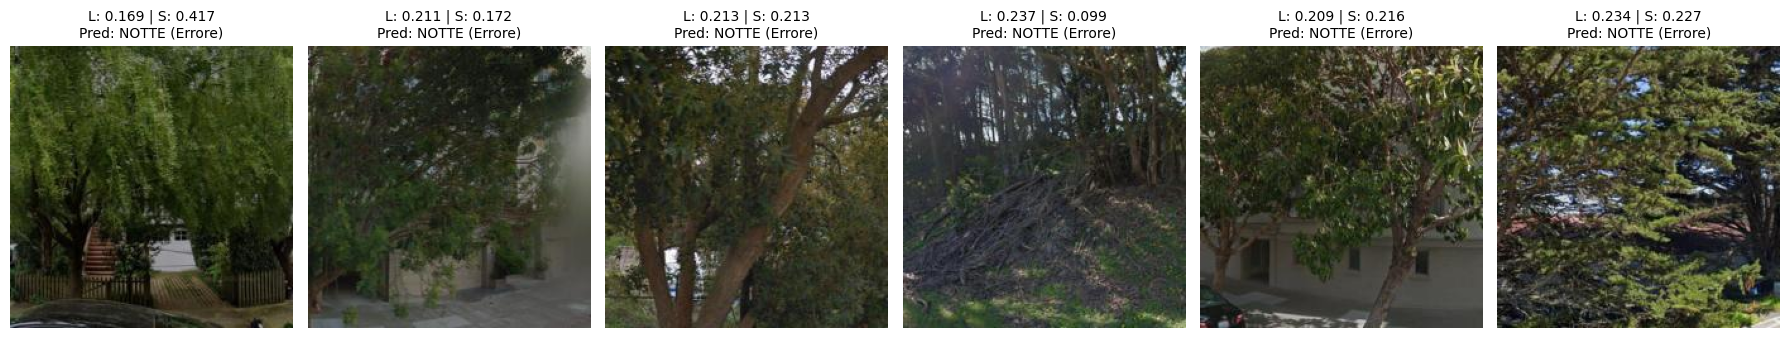

In [ ]:
import matplotlib.pyplot as plt
import cv2

indici_errori = []
for i, (l, s) in enumerate(zip(L_sfxs, S_sfxs)):
    if classifica_immagine(l, s) == "Notte":
        indici_errori.append(i)

max_immagini = 6
immagini_da_mostrare = indici_errori[:max_immagini]

if len(indici_errori) == 0:
    print("Eccezionale! L'algoritmo non ha commesso alcun errore su questo set.")
else:
    print(f"Trovati {len(indici_errori)} errori in totale. Ecco i primi {len(immagini_da_mostrare)} casi:")

    fig, axes = plt.subplots(1, len(immagini_da_mostrare), figsize=(18, 5))

    if len(immagini_da_mostrare) == 1:
        axes = [axes]

    for i, idx in enumerate(immagini_da_mostrare):
        path_immagine = sfxs_images[idx]
        l_val = L_sfxs[idx]
        s_val = S_sfxs[idx]

        img_bgr = cv2.imread(path_immagine)

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img_rgb)

        titolo = f"L: {l_val:.3f} | S: {s_val:.3f}\nPred: NOTTE (Errore)"
        axes[i].set_title(titolo, fontsize=10, color='black')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# APPLICAZIONE AI DATASET DI TEST
import json
import os

datasets = ['sf_xs', 'tokyo_xs', 'svox/sun', 'svox/night']
methods = ['superglue', 'loftr', 'superpoint-lg']

print(f"Metodo VPR selezionato: {vpr_method}")

# UTILS
def classifica_immagine(L_mean, S_mean):
    if L_mean > threshold_luminance_cv:    # Sicuri giorno
        return "Giorno"
    elif L_mean > 0.25 and S_mean < threshold_saturation_cv:   # Ombra o cielo nuvoloso
        return "Giorno"
    else:
        return "Notte"

dizionario_etichette_dominio = {}

# VERIFICA GIORNO/NOTTE SUI DATASET DI TEST
for dataset in datasets:

  if dataset.startswith("svox"):
    root_dataset, tipo = dataset.split('/')
    dataset_dir = Path(f"/content/Visual-Place-Recognition-Project/data/{root_dataset}/images/test/queries_{tipo}")
  else:
    dataset_dir = Path(f"/content/Visual-Place-Recognition-Project/data/{dataset}/test/queries")

  images = glob(os.path.join(dataset_dir, "**/*.jpg"), recursive=True)
  num_images = len(images)
  L, S = np.zeros(num_images), np.zeros(num_images)


  for i, path in enumerate(tqdm(images)):
    L[i], S[i] = luminance_cv2(path)

  predicted_day = 0
  predicted_night = 0


  for path, l, s in zip(images, L, S):
      predict = classifica_immagine(l, s)

      domain = "day" if predict == "Giorno" else "night"

      dizionario_etichette_dominio[path] = domain

      if domain == "day":
          predicted_day += 1
      else:
          predicted_night += 1

  # Calcoliamo le percentuali
  perc_day = (predicted_day / num_images) * 100
  perc_night = (predicted_night / num_images) * 100

  # Stampiamo il risultato finale
  print(f"Risultati Dataset: {dataset.upper()} ({num_images} query)")
  print(f"Giorno: {predicted_day} ({perc_day:.2f}%)")
  print(f"Notte:  {predicted_night} ({perc_night:.2f}%)")
  print("\n")

# SALVATAGGIO SU FILE JSON
json_path = "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/test_etichette_dominio.json"
with open(json_path, "w") as f:
  json.dump(dizionario_etichette_dominio, f, indent=4)

print(f"Classificazione salvata con successo in: {json_path}")




Metodo VPR selezionato: mixvpr


100%|██████████| 1000/1000 [00:00<00:00, 1383.19it/s]


Risultati Dataset: SF_XS (1000 query)
Giorno: 987 (98.70%)
Notte:  13 (1.30%)




100%|██████████| 315/315 [00:00<00:00, 1499.91it/s]


Risultati Dataset: TOKYO_XS (315 query)
Giorno: 220 (69.84%)
Notte:  95 (30.16%)




100%|██████████| 854/854 [00:01<00:00, 431.10it/s]


Risultati Dataset: SVOX/SUN (854 query)
Giorno: 854 (100.00%)
Notte:  0 (0.00%)




100%|██████████| 823/823 [00:01<00:00, 437.02it/s]

Risultati Dataset: SVOX/NIGHT (823 query)
Giorno: 50 (6.08%)
Notte:  773 (93.92%)


Classificazione salvata con successo in: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/test_etichette_dominio.json


# VALIDATION ADAPTIVE RERANKING WITH SUN/NIGHT RECOGNITION

In [ ]:
import cv2
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import re

%cd /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

datasets = ["sf_xs"]
methods = ["loftr", "superpoint-lg"]

project_data = Path("/content/Visual-Place-Recognition-Project/data")

root_dir = Path("/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods")
base_dir = root_dir / vpr_method

soglia_csv = base_dir / "soglia_r1.csv"
tempi_csv = base_dir / "tabella_finale_tempi_query.csv"

output_csv = Path(
    f"/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/validation/"
    f"Image_Matching_methods/{vpr_method}/adaptive_vs_full_reranking_luminance_direct.csv"
)

soglia_giornonotte = (
    f"/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training/"
    f"Image_Matching_methods/{vpr_method}/soglie_medie.txt"
)

soglie_giornonotte = {}

pattern = re.compile(
    r"^soglia_(sun|night)_(loftr|superpoint-lg)\s*=\s*([0-9]+(?:\.[0-9]+)?)"
)

with open(soglia_giornonotte, "r") as f:
    for line in f:
        line = line.strip()

        match = pattern.match(line)

        if match is None:
            continue

        luce = match.group(1)
        metodo = match.group(2)
        soglia = int(float(match.group(3)))

        if luce not in soglie_giornonotte:
            soglie_giornonotte[luce] = {}

        soglie_giornonotte[luce][metodo] = soglia


print("Soglie caricate:")

threshold_giorno = soglie_giornonotte["sun"]
threshold_notte = soglie_giornonotte["night"]

print(f"Metodo VPR: {vpr_method}")
print(f"Dataset: {datasets}")
print(f"Image matching methods: {methods}")


# ------------------------------------------------------------
# UTILS
# ------------------------------------------------------------

def luminance_cv2(path):

    img_bgr = cv2.imread(str(path))

    if img_bgr is None:
        raise ValueError(f"Impossibile leggere immagine:\n{path}")

    img_hls = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HLS)

    L_channel = img_hls[:, :, 1]
    S_channel = img_hls[:, :, 2]

    L_mean = np.mean(L_channel.flatten()) / 255.0
    S_mean = np.mean(S_channel.flatten()) / 255.0

    return L_mean, S_mean


def classifica_immagine(L_mean, S_mean):

    if L_mean > threshold_luminance_cv:
        return "sun"

    elif L_mean > 0.25 and S_mean < threshold_saturation_cv:
        return "sun"

    else:
        return "night"


def get_query_paths(dataset):

    query_dir = project_data / dataset / "val" / "queries"

    if not query_dir.exists():
        raise FileNotFoundError(f"Non trovo la cartella query:\n{query_dir}")

    estensioni = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    query_paths = sorted([
        p for p in query_dir.rglob("*")
        if p.suffix.lower() in estensioni
    ])

    if len(query_paths) == 0:
        raise FileNotFoundError(f"Nessuna query trovata in:\n{query_dir}")

    return query_paths


def get_reranking_timing(tempi_df, dataset, method):

    row = tempi_df[
        (tempi_df["Dataset"].astype(str) == str(dataset)) &
        (tempi_df["Metodo"].astype(str) == str(method))
    ]

    if len(row) == 0:
        return {
            "matching_mean_s": 0.0,
            "reranking_mean_s": 0.0,
        }

    row = row.iloc[0]

    return {
        "matching_mean_s": float(row.get("Matching_Mean_s", 0.0)),
        "reranking_mean_s": float(row.get("Reranking_Mean_s", 0.0)),
    }


# ------------------------------------------------------------
# CONTROLLI
# ------------------------------------------------------------

if "df_risultati_validation" not in globals():
    raise NameError("df_risultati_validation non esiste in memoria.")

if "threshold_luminance_cv" not in globals():
    raise NameError("threshold_luminance_cv non esiste in memoria.")

if "threshold_saturation_cv" not in globals():
    raise NameError("threshold_saturation_cv non esiste in memoria.")


# ------------------------------------------------------------
# CARICO CSV
# ------------------------------------------------------------

soglie_df = pd.read_csv(soglia_csv)
tempi_df = pd.read_csv(tempi_csv)

soglie_df["dataset"] = soglie_df["dataset"].astype(str)
soglie_df["method"] = soglie_df["method"].astype(str)

soglie_df = soglie_df[
    (soglie_df["dataset"].isin(datasets)) &
    (soglie_df["method"].isin(methods))
].copy()

if len(soglie_df) == 0:
    raise ValueError("Dopo il filtro non rimane nessuna riga in soglie_df.")

all_results = []


# ------------------------------------------------------------
# CICLO ESSENZIALE
# ------------------------------------------------------------

for _, row in soglie_df.iterrows():

    dataset = row["dataset"]
    method = row["method"]

    df_subset = df_risultati_validation[
        (df_risultati_validation["dataset"].astype(str) == str(dataset)) &
        (df_risultati_validation["method"].astype(str) == str(method))
    ].copy()

    if len(df_subset) == 0:
        print(f"Nessun dato per {dataset} / {method}. Skip.")
        continue

    if "query_jpg" not in df_subset.columns:
        raise ValueError("Nel dataframe manca la colonna query_jpg.")

    query_paths = get_query_paths(dataset)

    query_path_by_name = {
        p.name: p
        for p in query_paths
    }

    df_subset["k"] = df_subset["k"].astype(int)
    df_subset["rank1_inliers"] = df_subset["rank1_inliers"].astype(int)
    df_subset["base_correct"] = df_subset["base_correct"].astype(int)
    df_subset["full_correct"] = df_subset["full_correct"].astype(int)

    correct = 0

    n_easy_skip = 0
    n_hard_rerank = 0

    n_giorno = 0
    n_notte = 0

    matching_pairs_adaptive = 0
    matching_pairs_full = 0

    files_skipped = 0

    for _, q_row in tqdm(
        df_subset.iterrows(),
        total=len(df_subset),
        desc=f"{dataset} / {method}"
    ):

        query_jpg = str(q_row["query_jpg"]).strip()

        query_path = query_path_by_name.get(query_jpg)

        if query_path is None:
            files_skipped += 1
            print(f"Query presente nel CSV ma non trovata nella cartella immagini: {query_jpg}")
            continue

        try:
            L_mean, S_mean = luminance_cv2(query_path)
            light_class = classifica_immagine(L_mean, S_mean)

        except Exception as e:
            files_skipped += 1
            print(f"Skip immagine:\n{query_path}\n{e}")
            continue

        if light_class == "sun":
            threshold = threshold_giorno[method]
            n_giorno += 1

        else:
            threshold = threshold_notte[method]
            n_notte += 1

        k = int(q_row["k"])
        rank1_inliers = int(q_row["rank1_inliers"])

        base_correct = int(q_row["base_correct"])
        full_correct = int(q_row["full_correct"])

        matching_pairs_full += k

        if rank1_inliers >= threshold:
            # query facile: tengo il rank-1 originale
            correct += base_correct
            n_easy_skip += 1
            matching_pairs_adaptive += 1

        else:
            # query difficile: faccio full reranking
            correct += full_correct
            n_hard_rerank += 1
            matching_pairs_adaptive += k

    n_queries = n_easy_skip + n_hard_rerank

    if n_queries == 0:
        print(f"Nessuna query valida per {dataset} / {method}.")
        continue

    adaptive_r1 = 100 * correct / n_queries

    skip_queries_pct = 100 * n_easy_skip / n_queries
    rerank_queries_pct = 100 * n_hard_rerank / n_queries

    matching_pairs_vs_full_pct = 100 * matching_pairs_adaptive / matching_pairs_full
    matching_pairs_saving_pct = 100 - matching_pairs_vs_full_pct

    timing = get_reranking_timing(tempi_df, dataset, method)

    matching_mean_s = timing["matching_mean_s"]
    reranking_mean_s = timing["reranking_mean_s"]

    full_reranking_query_s = matching_mean_s + reranking_mean_s

    adaptive_reranking_query_s = (
        matching_mean_s * (matching_pairs_vs_full_pct / 100)
        +
        reranking_mean_s * (rerank_queries_pct / 100)
    )

    reranking_time_saving_pct = 100 * (
        1 - adaptive_reranking_query_s / full_reranking_query_s
    ) if full_reranking_query_s > 0 else np.nan

    res = {
        "dataset": dataset,
        "method": method,

        "threshold_giorno": threshold_giorno[method],
        "threshold_notte": threshold_notte[method],

        "adaptive_R@1": adaptive_r1,

        "n_queries": n_queries,
        "files_skipped": files_skipped,

        "n_giorno": n_giorno,
        "n_notte": n_notte,
        "giorno_%": 100 * n_giorno / n_queries,
        "notte_%": 100 * n_notte / n_queries,

        "n_easy_skip": n_easy_skip,
        "n_hard_rerank": n_hard_rerank,
        "skip_queries_%": skip_queries_pct,
        "rerank_queries_%": rerank_queries_pct,

        "matching_pairs_adaptive": matching_pairs_adaptive,
        "matching_pairs_full": matching_pairs_full,
        "matching_pairs_vs_full_%": matching_pairs_vs_full_pct,
        "matching_pairs_saving_%": matching_pairs_saving_pct,

        "matching_mean_s": matching_mean_s,
        "reranking_mean_s": reranking_mean_s,

        "full_reranking_query_s": full_reranking_query_s,
        "adaptive_reranking_query_s": adaptive_reranking_query_s,

        "full_reranking_query_ms": full_reranking_query_s * 1000,
        "adaptive_reranking_query_ms": adaptive_reranking_query_s * 1000,

        "reranking_time_saving_%": reranking_time_saving_pct,
    }

    all_results.append(res)

    print(
        f"{dataset:<10} | {method:<15} | "
        f"R@1={adaptive_r1:>6.2f}% | "
        f"giorno={100 * n_giorno / n_queries:>6.2f}% | "
        f"notte={100 * n_notte / n_queries:>6.2f}% | "
        f"skip={skip_queries_pct:>6.2f}% | "
        f"rerank={rerank_queries_pct:>6.2f}% | "
        f"saving={reranking_time_saving_pct:>6.2f}%"
    )


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

if len(all_results) > 0:

    results_df = pd.DataFrame(all_results)

    output_csv.parent.mkdir(parents=True, exist_ok=True)
    results_df.to_csv(output_csv, index=False)

    print("\n✅ Summary salvato in:")
    print(output_csv)

    display(results_df)

else:
    print("❌ Nessun risultato prodotto.")

TESTING ADAPTIVE RERANKING WITH SUN/NIGHT RECOGNITION

In [ ]:
import cv2
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import re

%cd /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/

datasets = ["sf_xs", "tokyo_xs", "svox/sun", "svox/night"]
methods = ["loftr", "superpoint-lg"]

project_data = Path("/content/Visual-Place-Recognition-Project/data")

root_dir = Path("/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods")
base_dir = root_dir / vpr_method

soglia_csv = base_dir / "soglia_r1.csv"
tempi_csv = base_dir / "tabella_finale_tempi_query.csv"

output_csv = Path(
    f"/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/test/"
    f"Image_Matching_methods/{vpr_method}/adaptive_vs_full_reranking_luminance_direct.csv"
)

soglia_giornonotte = (
    f"/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training/"
    f"Image_Matching_methods/{vpr_method}/soglie_medie.txt"
)

soglie_giornonotte = {}

pattern = re.compile(
    r"^soglia_(sun|night)_(loftr|superpoint-lg)\s*=\s*([0-9]+(?:\.[0-9]+)?)"
)

with open(soglia_giornonotte, "r") as f:
    for line in f:
        line = line.strip()

        match = pattern.match(line)

        if match is None:
            continue

        luce = match.group(1)
        metodo = match.group(2)
        soglia = int(float(match.group(3)))

        if luce not in soglie_giornonotte:
            soglie_giornonotte[luce] = {}

        soglie_giornonotte[luce][metodo] = soglia


print("Soglie caricate:")

threshold_giorno = soglie_giornonotte["sun"]
threshold_notte = soglie_giornonotte["night"]

print(f"Metodo VPR: {vpr_method}")
print(f"Dataset: {datasets}")
print(f"Image matching methods: {methods}")


# ------------------------------------------------------------
# UTILS
# ------------------------------------------------------------

def luminance_cv2(path):

    img_bgr = cv2.imread(str(path))

    if img_bgr is None:
        raise ValueError(f"Impossibile leggere immagine:\n{path}")

    img_hls = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HLS)

    L_channel = img_hls[:, :, 1]
    S_channel = img_hls[:, :, 2]

    L_mean = np.mean(L_channel.flatten()) / 255.0
    S_mean = np.mean(S_channel.flatten()) / 255.0

    return L_mean, S_mean


def classifica_immagine(L_mean, S_mean):

    if L_mean > threshold_luminance_cv:
        return "sun"

    elif L_mean > 0.25 and S_mean < threshold_saturation_cv:
        return "sun"

    else:
        return "night"


def get_query_paths(dataset):

    if dataset == "svox/sun" or dataset == "svox/night":

        root_dataset, light_type = dataset.split("/")   # "svox", "sun" oppure "night"

        query_dir = (
            project_data
            / root_dataset
            / "images"
            / "test"
            / f"queries_{light_type}"
        )

    else:

        query_dir = (
            project_data
            / dataset
            / "test"
            / "queries"
        )

    if not query_dir.exists():
        raise FileNotFoundError(f"Non trovo la cartella query:\n{query_dir}")

    estensioni = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    query_paths = sorted([
        p for p in query_dir.rglob("*")
        if p.suffix.lower() in estensioni
    ])

    if len(query_paths) == 0:
        raise FileNotFoundError(f"Nessuna query trovata in:\n{query_dir}")

    return query_paths


def get_reranking_timing(tempi_df, dataset, method):

    row = tempi_df[
        (tempi_df["Dataset"].astype(str) == str(dataset)) &
        (tempi_df["Metodo"].astype(str) == str(method))
    ]

    if len(row) == 0:
        return {
            "matching_mean_s": 0.0,
            "reranking_mean_s": 0.0,
        }

    row = row.iloc[0]

    return {
        "matching_mean_s": float(row.get("Matching_Mean_s", 0.0)),
        "reranking_mean_s": float(row.get("Reranking_Mean_s", 0.0)),
    }


# ------------------------------------------------------------
# CONTROLLI
# ------------------------------------------------------------

if "df_risultati" not in globals():
    raise NameError("df_risultati non esiste in memoria.")

if "threshold_luminance_cv" not in globals():
    raise NameError("threshold_luminance_cv non esiste in memoria.")

if "threshold_saturation_cv" not in globals():
    raise NameError("threshold_saturation_cv non esiste in memoria.")


# ------------------------------------------------------------
# CARICO CSV
# ------------------------------------------------------------

soglie_df = pd.read_csv(soglia_csv)
tempi_df = pd.read_csv(tempi_csv)

soglie_df["dataset"] = soglie_df["dataset"].astype(str)
soglie_df["method"] = soglie_df["method"].astype(str)

soglie_df = soglie_df[
    (soglie_df["dataset"].isin(datasets)) &
    (soglie_df["method"].isin(methods))
].copy()

if len(soglie_df) == 0:
    raise ValueError("Dopo il filtro non rimane nessuna riga in soglie_df.")

all_results = []


# ------------------------------------------------------------
# CICLO ESSENZIALE
# ------------------------------------------------------------

for _, row in soglie_df.iterrows():

    dataset = row["dataset"]
    method = row["method"]

    df_subset = df_risultati[
        (df_risultati["dataset"].astype(str) == str(dataset)) &
        (df_risultati["method"].astype(str) == str(method))
    ].copy()

    if len(df_subset) == 0:
        print(f"Nessun dato per {dataset} / {method}. Skip.")
        continue

    if "query_jpg" not in df_subset.columns:
        raise ValueError("Nel dataframe manca la colonna query_jpg.")

    query_paths = get_query_paths(dataset)

    query_path_by_name = {
        p.name: p
        for p in query_paths
    }

    df_subset["k"] = df_subset["k"].astype(int)
    df_subset["rank1_inliers"] = df_subset["rank1_inliers"].astype(int)
    df_subset["base_correct"] = df_subset["base_correct"].astype(int)
    df_subset["full_correct"] = df_subset["full_correct"].astype(int)

    correct = 0

    n_easy_skip = 0
    n_hard_rerank = 0

    n_giorno = 0
    n_notte = 0

    matching_pairs_adaptive = 0
    matching_pairs_full = 0

    files_skipped = 0

    for _, q_row in tqdm(
        df_subset.iterrows(),
        total=len(df_subset),
        desc=f"{dataset} / {method}"
    ):

        query_jpg = str(q_row["query_jpg"]).strip()

        query_path = query_path_by_name.get(query_jpg)

        if query_path is None:
            files_skipped += 1
            print(f"Query presente nel CSV ma non trovata nella cartella immagini: {query_jpg}")
            continue

        try:
            L_mean, S_mean = luminance_cv2(query_path)
            light_class = classifica_immagine(L_mean, S_mean)

        except Exception as e:
            files_skipped += 1
            print(f"Skip immagine:\n{query_path}\n{e}")
            continue

        if light_class == "sun":
            threshold = threshold_giorno[method]
            n_giorno += 1

        else:
            threshold = threshold_notte[method]
            n_notte += 1

        k = int(q_row["k"])
        rank1_inliers = int(q_row["rank1_inliers"])

        base_correct = int(q_row["base_correct"])
        full_correct = int(q_row["full_correct"])

        matching_pairs_full += k

        if rank1_inliers >= threshold:
            # query facile: tengo il rank-1 originale
            correct += base_correct
            n_easy_skip += 1
            matching_pairs_adaptive += 1

        else:
            # query difficile: faccio full reranking
            correct += full_correct
            n_hard_rerank += 1
            matching_pairs_adaptive += k

    n_queries = n_easy_skip + n_hard_rerank

    if n_queries == 0:
        print(f"Nessuna query valida per {dataset} / {method}.")
        continue

    adaptive_r1 = 100 * correct / n_queries

    skip_queries_pct = 100 * n_easy_skip / n_queries
    rerank_queries_pct = 100 * n_hard_rerank / n_queries

    matching_pairs_vs_full_pct = 100 * matching_pairs_adaptive / matching_pairs_full
    matching_pairs_saving_pct = 100 - matching_pairs_vs_full_pct

    timing = get_reranking_timing(tempi_df, dataset, method)

    matching_mean_s = timing["matching_mean_s"]
    reranking_mean_s = timing["reranking_mean_s"]

    full_reranking_query_s = matching_mean_s + reranking_mean_s

    adaptive_reranking_query_s = (
        matching_mean_s * (matching_pairs_vs_full_pct / 100)
        +
        reranking_mean_s * (rerank_queries_pct / 100)
    )

    reranking_time_saving_pct = 100 * (
        1 - adaptive_reranking_query_s / full_reranking_query_s
    ) if full_reranking_query_s > 0 else np.nan

    res = {
        "dataset": dataset,
        "method": method,

        "threshold_giorno": threshold_giorno[method],
        "threshold_notte": threshold_notte[method],

        "adaptive_R@1": adaptive_r1,

        "n_queries": n_queries,
        "files_skipped": files_skipped,

        "n_giorno": n_giorno,
        "n_notte": n_notte,
        "giorno_%": 100 * n_giorno / n_queries,
        "notte_%": 100 * n_notte / n_queries,

        "n_easy_skip": n_easy_skip,
        "n_hard_rerank": n_hard_rerank,
        "skip_queries_%": skip_queries_pct,
        "rerank_queries_%": rerank_queries_pct,

        "matching_pairs_adaptive": matching_pairs_adaptive,
        "matching_pairs_full": matching_pairs_full,
        "matching_pairs_vs_full_%": matching_pairs_vs_full_pct,
        "matching_pairs_saving_%": matching_pairs_saving_pct,

        "matching_mean_s": matching_mean_s,
        "reranking_mean_s": reranking_mean_s,

        "full_reranking_query_s": full_reranking_query_s,
        "adaptive_reranking_query_s": adaptive_reranking_query_s,

        "full_reranking_query_ms": full_reranking_query_s * 1000,
        "adaptive_reranking_query_ms": adaptive_reranking_query_s * 1000,

        "reranking_time_saving_%": reranking_time_saving_pct,
    }

    all_results.append(res)

    print(
        f"{dataset:<10} | {method:<15} | "
        f"R@1={adaptive_r1:>6.2f}% | "
        f"giorno={100 * n_giorno / n_queries:>6.2f}% | "
        f"notte={100 * n_notte / n_queries:>6.2f}% | "
        f"skip={skip_queries_pct:>6.2f}% | "
        f"rerank={rerank_queries_pct:>6.2f}% | "
        f"saving={reranking_time_saving_pct:>6.2f}%"
    )


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

if len(all_results) > 0:

    results_df = pd.DataFrame(all_results)

    output_csv.parent.mkdir(parents=True, exist_ok=True)
    results_df.to_csv(output_csv, index=False)

    print("\n✅ Summary salvato in:")
    print(output_csv)

    display(results_df)

else:
    print("❌ Nessun risultato prodotto.")

In [30]:
q0 = df_risultati_validation.loc[0, "query_jpg"]
q0

'@0543054.80@4180506.68@10@S@037.77088@-122.51113@XVGEMxgV2WGbeoitr2sIaw@@0@@@@202012@@.jpg'